# **Section 1: Exploratory data analysis and data cleaning**

## **Author**
Ophélie Rutschmann

## **Introduction**
This project uses a house price dataset compiled and published by Dean De Cock, which contains 2,930 observations across 82 features. The original data, sourced directly from the Ames Assessor’s Office, was collected for tax assessment purposes.

The primary goal of this project is to develop and evaluate models that can accurately predict house prices based on the available features. This notebook focuses on the first phase of the project: Exploratory Data Analysis (EDA) and Data Cleaning, which is important for building robust models later on.

## **Methods**

The objective of this section is to gain a better understanding of the dataset through exploratory data analysis and visualizations. By examining the distributions and patterns within the data, I want to identify potential issues such as missing or inconsistent values, errors, and outliers. Once the issues have been identified, I will clean the data using different methodologies. 

In this notebook, I will clean both the **training** and the **test** data sets. I will first clean the **training** data set, and then also clean the **test** data set using parameters obtained from the training data set. The cleaning of the test data set will mainly focus on filling missing values and addressing errors. I will not filter out outliers for instance, as this would result in an artifically "clean" test data set.

These are the following data cleaning steps that I did on the **training** data set:
- Removing duplicated rows
- Removing entirely empty rows / columns
- Filling in missing values
- Correcting incorrect values (either by filling them in or removing them)
- Removing features with low correlation to sale pirce
- Removing possible co-linear features
- Removing outliers (continuous features)
- Removing rare values (discrete features)
- Grouping / removing rare categories (nominal and ordinal features)

For the **test** data set, I followed a simplified approach based on the following steps:
- Removing duplicated rows
- Removing entirely empty rows / columns
- Filling in missing values
- Correcting incorrect values (only by filling them)
- Removing features with low correlation to sale pirce
- Removing possible co-linear features

This method ensures that I do not remove any entry from the test data set, which could result in an artificially "easier" data set which could inflate model performance.

## **Table of content**

This notebook is separated into the following sections:
1. **Preliminary EDA and data cleaning**
    - 1.1 Preliminary data set exploration
    - 1.2 Removing duplicated rows
    - 1.3 Removing empty rows / columns
2. **Exploratory data analysis**
    - 2.1 Continuous variables
        - a) Identifying missing values
        - b) Identifying values with the wrong data type
        - c) Identifying and removing incorrect values
        - d) Removing features with low correlation to sale price
        - e) Removing possible colinear features
    - 2.2 Discrete variables
        - a) Identifying missing values
        - b) Identifying values with the wrong data type
        - c) Identifying and removing incorrect values
        - d) Removing features with low correlation to sale price
        - e) Removing possible colinear features
    - 2.3 Nominal variables
        - a) Identifying missing values
        - b) Removing features with low impact on sale price    
    - 2.3 Ordinal variables
        - a) Identifying missing values
        - b) Removing features with low impact on sale price
3. **Sale Price distribution**
    - 3.1 Plotting the distribution
    - 3.2 Identifying outliers
4. **Outlier Removal**
    - 4.1 Identifying outliers for the continuous variables
    - 4.2 Identifying rare/extreme values for the discrete variables
    - 4.3 Identifying rare values for the nominal variables
    - 4.4 Identifying rare values for the ordinal variables
    - 4.5 Filtering the training data set
5. **Summary**
6. **Saving the cleaned data**


## **Academic Integrity and Learning Statement**

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


## **1) Preliminary data cleaning**

Before diving into the exploratory data analysis, we can already gain some understanding of our data set by doing a preliminary data set exploration and some preliminary data cleaning steps such as removing duplicated rows and removing entirely empty rows / columns. Let's start by importing the data set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import the training data set
data = pd.read_csv("house-prices.csv")
data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,484,528275070,60,RL,NaN,8795,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,236000
1,2586,535305120,20,RL,75.0,10170,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,155000
2,2289,923228250,160,RM,21.0,2001,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,75000
3,142,535152150,20,RL,70.0,10552,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,165500
4,2042,903475060,190,RM,60.0,10120,Pave,NaN,IR1,Bnk,...,0,NaN,MnPrv,NaN,0,1,2007,WD,Normal,122000


In [3]:
# Import the test data set
data_test = pd.read_csv("house-prices-test.csv")
data_test.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,2217,909279080,50,RL,NaN,11275,Pave,NaN,IR1,HLS,...,0,0,NaN,NaN,NaN,0,3,2007,WD,Normal
1,837,907126050,20,RL,65.0,9757,Pave,NaN,Reg,Low,...,92,0,NaN,NaN,NaN,0,10,2009,WD,Normal
2,2397,528144030,60,RL,86.0,11065,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,10,2006,New,Partial
3,1963,535452060,20,RL,70.0,7000,Pave,NaN,Reg,Lvl,...,0,0,NaN,MnWw,NaN,0,4,2007,WD,Family
4,306,911202100,50,C (all),66.0,8712,Pave,Pave,Reg,HLS,...,0,0,NaN,NaN,NaN,0,1,2010,WD,Abnorml


### **1.1) Preliminary data set exploration**

Based on the description in the data documentation, we know that the data contains 82 columns:
- 23 nominal variables
- 23 ordinal variables
- 14 discrete variables
- 20 continuous variables
- 2 additional observation identifiers

We can check our data frame to make sure this is what we have. 

In [4]:
print(data.shape)

(2430, 82)


In [5]:
print(data.columns)

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

It looks like our data set contains the expected columns and consists of 2430 entries with 82 features each. 
From the description, we know that the columns "PID" and "Order" are identifiers and not useful for our model. We can remove them. For all future analysis steps, we will work on a copy of our data frame. 

In [6]:
df = data.copy()
df_test = data_test.copy()

Let's also keep track of the features we removed.

In [7]:
feat_del = []
feat_del_test = []

In [8]:
df = df.drop(["PID", "Order"], axis=1)
df_test = df_test.drop(["PID", "Order"], axis=1)
feat_del.extend(["PID", "Order"])
feat_del_test.extend(["PID", "Order"])                 

In [9]:
df_test.shape

(500, 79)

In [10]:
df.shape

(2430, 80)

This is good, we have a test data frame with one column less than the training data set, which is expected (it doesn't contain the SalePrice). 

### **1.2) Removing duplicated rows**
Let's now check if our data set contains any duplicated rows, and if yes, let's remove them.

In [11]:
print("our data set contains", df.duplicated().sum(), "duplicated rows")
print("our test data set contains", df_test.duplicated().sum(), "duplicated rows")

our data set contains 0 duplicated rows
our test data set contains 0 duplicated rows


Good! It looks like our data set does not contain duplicated rows!

### **1.3) Removing entirely empty rows or columns**
Let's check if any rows or columns are entirely empty, and if yes, let's remove them.

In [12]:
print("our data set contains", df.isna().all(axis=1).sum(), "empty rows")
print("our data set contains", df.isna().all(axis=0).sum(), "empty columns")
print("our test data set contains", df_test.isna().all(axis=1).sum(), "empty rows")
print("our test data set contains", df_test.isna().all(axis=0).sum(), "empty columns")

our data set contains 0 empty rows
our data set contains 0 empty columns
our test data set contains 0 empty rows
our test data set contains 0 empty columns


Perfect, we have zero empty rows or columns. We can move on to the next steps.

## **2) Exploratory data analysis**

We can now perform some more in depth exploratory data analysis on our data set. We will perform this data analysis independently for each type of variable (nominal, ordinal, discrete and continuous). 

We will start by creating variables that contain the column names for each type of variable.

In [13]:
# create variables with the column names
nom_col = ["MS SubClass", "MS Zoning", "Street", "Alley", "Land Contour", 
           "Lot Config", "Neighborhood", "Condition 1", "Condition 2", "Bldg Type", "House Style",
           "Roof Style", "Roof Matl", "Exterior 1st", "Exterior 2nd", "Mas Vnr Type", "Foundation", 
           "Heating", "Central Air", "Garage Type", "Misc Feature", "Sale Type", "Sale Condition"]

ord_col = ["Lot Shape", "Utilities", "Land Slope", "Overall Qual", "Overall Cond", "Exter Qual", 
           "Exter Cond", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2",
           "Heating QC", "Electrical", "Kitchen Qual", "Functional", "Fireplace Qu", "Garage Finish", 
           "Garage Qual", "Garage Cond", "Paved Drive", "Pool QC", "Fence"]

disc_col = ["Year Built", "Year Remod/Add", "Bsmt Full Bath", "Bsmt Half Bath", "Full Bath", 
            "Half Bath", "Bedroom AbvGr", "Kitchen AbvGr", "TotRms AbvGrd", "Fireplaces", "Garage Yr Blt", 
            "Garage Cars", "Mo Sold", "Yr Sold"]

cont_col = ["Lot Frontage", "Lot Area", "Mas Vnr Area", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF",
            "Total Bsmt SF", "1st Flr SF", "2nd Flr SF", "Low Qual Fin SF", "Gr Liv Area", "Garage Area", 
            "Wood Deck SF", "Open Porch SF", "Enclosed Porch", "3Ssn Porch", "Screen Porch", "Pool Area", 
            "Misc Val"]

ids = ["Order", "PID"]

Now that we have created the lists with the column names, we can explore each of the variables. 

### **2.1) Exploring the continuous variables**

We will start by exploring the continuous variables by creating visualisations such as scatter plots and histograms to understand what the distributions look like, if there are variables that we want to remove, and what the best strategy for data cleaning is. 

#### **a) Identifying missing values**

Let's first have a look to see if we observe any missing values in the training data set. 

In [14]:
# identify missing values
for col in cont_col:
    print("Missing values for", col, ":", df[col].isna().sum(), "(", df[col].isna().sum() / len(df) * 100, "% )")

Missing values for Lot Frontage : 420 ( 17.28395061728395 % )
Missing values for Lot Area : 0 ( 0.0 % )
Missing values for Mas Vnr Area : 20 ( 0.823045267489712 % )
Missing values for BsmtFin SF 1 : 1 ( 0.0411522633744856 % )
Missing values for BsmtFin SF 2 : 1 ( 0.0411522633744856 % )
Missing values for Bsmt Unf SF : 1 ( 0.0411522633744856 % )
Missing values for Total Bsmt SF : 1 ( 0.0411522633744856 % )
Missing values for 1st Flr SF : 0 ( 0.0 % )
Missing values for 2nd Flr SF : 0 ( 0.0 % )
Missing values for Low Qual Fin SF : 0 ( 0.0 % )
Missing values for Gr Liv Area : 0 ( 0.0 % )
Missing values for Garage Area : 1 ( 0.0411522633744856 % )
Missing values for Wood Deck SF : 0 ( 0.0 % )
Missing values for Open Porch SF : 0 ( 0.0 % )
Missing values for Enclosed Porch : 0 ( 0.0 % )
Missing values for 3Ssn Porch : 0 ( 0.0 % )
Missing values for Screen Porch : 0 ( 0.0 % )
Missing values for Pool Area : 0 ( 0.0 % )
Missing values for Misc Val : 0 ( 0.0 % )


We observe that the data contains relatively few missing values in the continuous columns. The two main problematic columns are:
- Lot Frontage (The linear feet of street connected to the property)
- Mas Vnr Area (the area of the house that has masonry)

Let's quickly check if this is similar for the test data set.

In [15]:
# identify missing values
for col in cont_col:
    print("Missing values for", col, ":", df_test[col].isna().sum(), "(", df_test[col].isna().sum() / len(df_test) * 100, "% )")

Missing values for Lot Frontage : 70 ( 14.000000000000002 % )
Missing values for Lot Area : 0 ( 0.0 % )
Missing values for Mas Vnr Area : 3 ( 0.6 % )
Missing values for BsmtFin SF 1 : 0 ( 0.0 % )
Missing values for BsmtFin SF 2 : 0 ( 0.0 % )
Missing values for Bsmt Unf SF : 0 ( 0.0 % )
Missing values for Total Bsmt SF : 0 ( 0.0 % )
Missing values for 1st Flr SF : 0 ( 0.0 % )
Missing values for 2nd Flr SF : 0 ( 0.0 % )
Missing values for Low Qual Fin SF : 0 ( 0.0 % )
Missing values for Gr Liv Area : 0 ( 0.0 % )
Missing values for Garage Area : 0 ( 0.0 % )
Missing values for Wood Deck SF : 0 ( 0.0 % )
Missing values for Open Porch SF : 0 ( 0.0 % )
Missing values for Enclosed Porch : 0 ( 0.0 % )
Missing values for 3Ssn Porch : 0 ( 0.0 % )
Missing values for Screen Porch : 0 ( 0.0 % )
Missing values for Pool Area : 0 ( 0.0 % )
Missing values for Misc Val : 0 ( 0.0 % )


The problematic is similar for the test set, with both the Lot Frontage and the Mas Vnr Area features containing missing values.

##### **Adressing the Lot Frontage feature**
We will start by looking into more detail into the lot frontage variable. We can plot a histogram of this variable and it's relationship to the sale price. This can allow us to see if we could take the mean or the median of the distribution to fill in the missing values

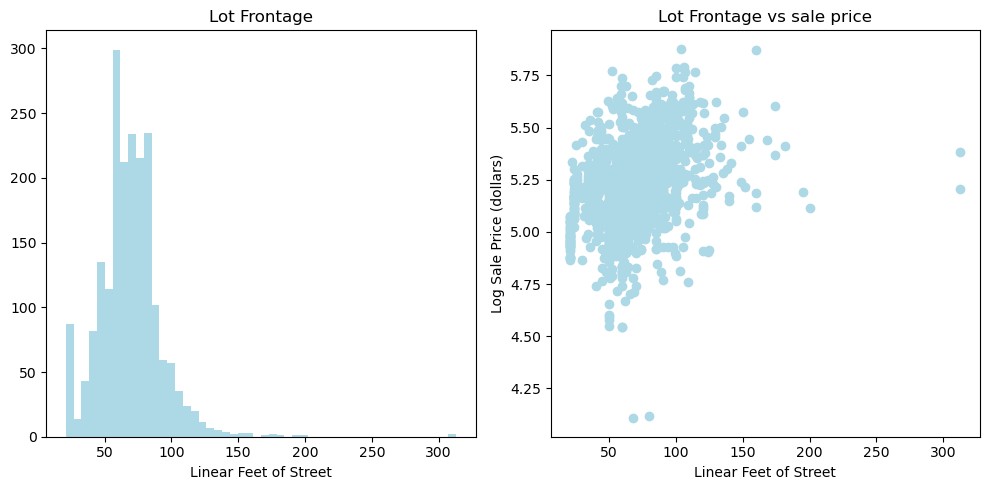

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(df["Lot Frontage"], bins=50, color="lightblue")
axes[0].set_title("Lot Frontage")
axes[0].set_xlabel("Linear Feet of Street")

axes[1].scatter(x=df["Lot Frontage"], y=np.log10(df["SalePrice"]), color="lightblue")
axes[1].set_title("Lot Frontage vs sale price")
axes[1].set_xlabel("Linear Feet of Street")
axes[1].set_ylabel("Log Sale Price (dollars)")
plt.tight_layout()
plt.show()

These plots show us that the distribution seems to contain a tail to the right. Taking the mean of the distribution is thus likely not a good approach to fill in the missing values. We could fill in the missing values by taking the median of the distribution. But let's first have a look if there are other variables that could influence the lot frontage (such as the neighbourhood or the zoning of the house) and could help us refine the approache we would like to take to fill in the missing values. 

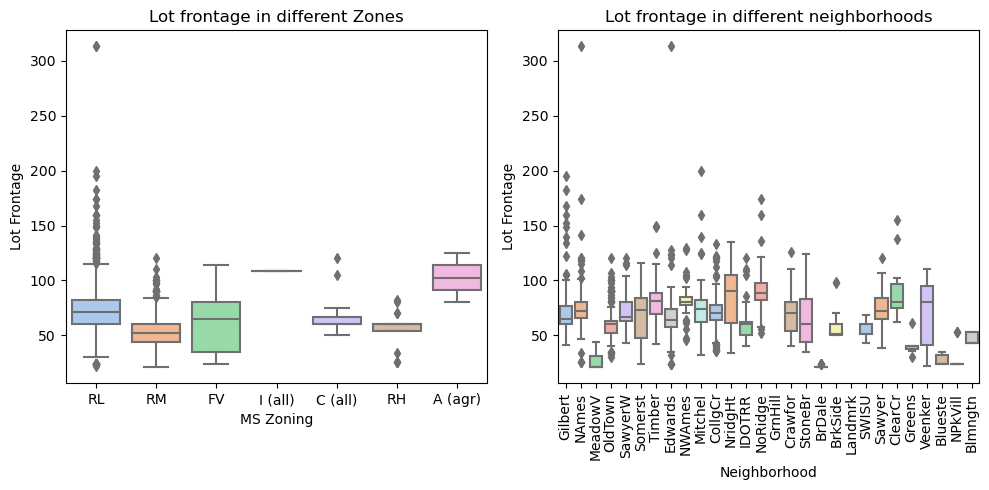

In [17]:
# Let's look if the zoning and neighborhood influences the lot frontage
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.boxplot(data=df, x="MS Zoning", y="Lot Frontage", ax=axes[0], palette="pastel")
axes[0].set_title("Lot frontage in different Zones")
sns.boxplot(data=df, x="Neighborhood", y="Lot Frontage", ax=axes[1], palette="pastel")
axes[1].set_title("Lot frontage in different neighborhoods")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

Both the zonage and the neighborhood seem to have an effect on the lot frontage. Taking the median lot frontage for each zone or each neighborhood could both thus be viable approaches to fill in the missing values. 

I have decided to take the median value of the lot frontage depending on the neighborhood, as this approach seems more refined (there are more neighborhoods than zones). 

In [18]:
# obtain the median lot frontage for each neighborhood
med_nbrh = df.groupby("Neighborhood")["Lot Frontage"].median()

# make a list that contains the median lot frontage of each house's neighborhood
med_lot_frontage = df["Neighborhood"].map(med_nbrh.to_dict())

# replace the empty values with the values in this list
df["Lot Frontage"] = df["Lot Frontage"].fillna(med_lot_frontage)

print("after cleaning, we have", df["Lot Frontage"].isna().sum(), "missing values")

after cleaning, we have 3 missing values


This approach filled all of the missing values except for 3 (likely houses that don't have a neighborhood specified). For these houses, we can fill the missing values using the median of the whole data set.

In [19]:
df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

print("after cleaning, we have", df["Lot Frontage"].isna().sum(), "missing values")

after cleaning, we have 0 missing values


Let's now apply this method to clean the **test** data set, using the medians from the **training** data set!

In [20]:
# obtain the median lot frontage for each neighborhood from the training set
med_nbrh = df.groupby("Neighborhood")["Lot Frontage"].median()

# make a list that contains the median lot frontage of each house's neighborhood
med_lot_frontage = df_test["Neighborhood"].map(med_nbrh.to_dict())

# Replace the missing values with the values from the list
df_test["Lot Frontage"] = df_test["Lot Frontage"].fillna(med_lot_frontage)

print("after cleaning we have", df_test["Lot Frontage"].isna().sum(), "missing values")

after cleaning we have 0 missing values


##### **Adressing the Mas Vnr Area feature**
The next column we would like to adress is the column Mas Vnr Area (the area of the house that has masonry)

We will start by making a histogram of this variable and it's relationship to the sale price.

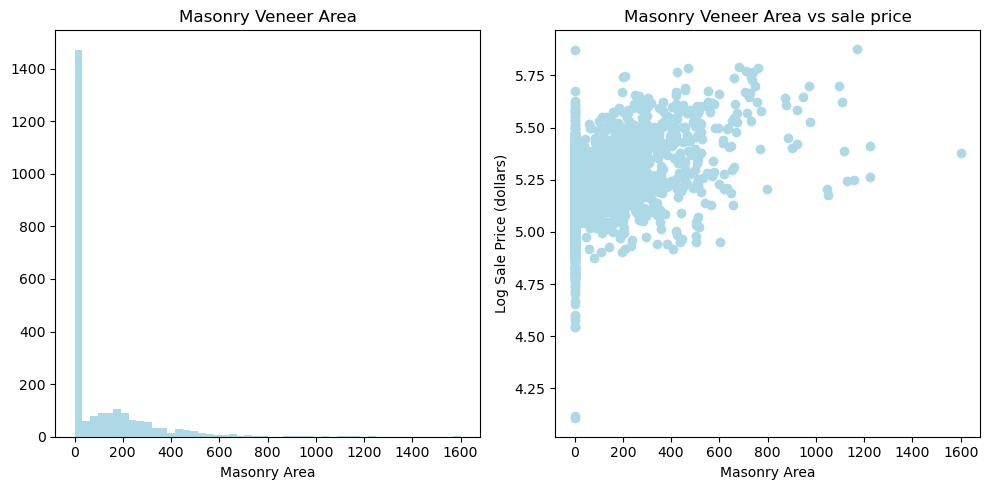

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(df["Mas Vnr Area"], bins=50, color="lightblue")
axes[0].set_title("Masonry Veneer Area")
axes[0].set_xlabel("Masonry Area")

axes[1].scatter(x=df["Mas Vnr Area"], y=np.log10(df["SalePrice"]), color="lightblue")
axes[1].set_title("Masonry Veneer Area vs sale price")
axes[1].set_xlabel("Masonry Area")
axes[1].set_ylabel("Log Sale Price (dollars)")
plt.tight_layout()
plt.show()

We immediately see that a lot of the houses have a Masonry Veneer Area of 0, likely meaning that they do not have any masonry veneer. This is an issue of itself that we can adress later on. For now, we can take the approach of filling the missing values with a 0 as well.

In [22]:
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(0)
df["Mas Vnr Area"].isna().sum()

0

Let's apply the same methodology to the **test** set.

In [23]:
df_test["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(0)
df_test["Mas Vnr Area"].isna().sum()

0

##### **Filling in the other missing values**
Finally, for all of the other continuous variables with missing values, we can also replace them with 0, indicating the absence of the feature. Let's do this for both the training and the test sets.

In [24]:
df[cont_col] = df[cont_col].fillna(0)
df[cont_col].isna().sum()

Lot Frontage       0
Lot Area           0
Mas Vnr Area       0
BsmtFin SF 1       0
BsmtFin SF 2       0
Bsmt Unf SF        0
Total Bsmt SF      0
1st Flr SF         0
2nd Flr SF         0
Low Qual Fin SF    0
Gr Liv Area        0
Garage Area        0
Wood Deck SF       0
Open Porch SF      0
Enclosed Porch     0
3Ssn Porch         0
Screen Porch       0
Pool Area          0
Misc Val           0
dtype: int64

In [25]:
df_test[cont_col] = df[cont_col].fillna(0)
df_test[cont_col].isna().sum()

Lot Frontage       0
Lot Area           0
Mas Vnr Area       0
BsmtFin SF 1       0
BsmtFin SF 2       0
Bsmt Unf SF        0
Total Bsmt SF      0
1st Flr SF         0
2nd Flr SF         0
Low Qual Fin SF    0
Gr Liv Area        0
Garage Area        0
Wood Deck SF       0
Open Porch SF      0
Enclosed Porch     0
3Ssn Porch         0
Screen Porch       0
Pool Area          0
Misc Val           0
dtype: int64

#### **b) Identifying data type inconsistencies**

Now that we have filled in any missing values, we can quickly have a look if we see any other problematic values in the variables. These are continuous variable, the data type should be numerical. We can check if this is the case for all of the values.

In [26]:
df[cont_col].dtypes

Lot Frontage       float64
Lot Area             int64
Mas Vnr Area       float64
BsmtFin SF 1       float64
BsmtFin SF 2       float64
Bsmt Unf SF        float64
Total Bsmt SF      float64
1st Flr SF           int64
2nd Flr SF           int64
Low Qual Fin SF      int64
Gr Liv Area          int64
Garage Area        float64
Wood Deck SF         int64
Open Porch SF        int64
Enclosed Porch       int64
3Ssn Porch           int64
Screen Porch         int64
Pool Area            int64
Misc Val             int64
dtype: object

In [27]:
df_test[cont_col].dtypes

Lot Frontage       float64
Lot Area             int64
Mas Vnr Area       float64
BsmtFin SF 1       float64
BsmtFin SF 2       float64
Bsmt Unf SF        float64
Total Bsmt SF      float64
1st Flr SF           int64
2nd Flr SF           int64
Low Qual Fin SF      int64
Gr Liv Area          int64
Garage Area        float64
Wood Deck SF         int64
Open Porch SF        int64
Enclosed Porch       int64
3Ssn Porch           int64
Screen Porch         int64
Pool Area            int64
Misc Val             int64
dtype: object

All of the variables seem to contain the correct data type, either float or int.

#### **c) Identifying incorrect values**

Before we adress outliers and 0s in the data set, we can have a look at whether the values in our features are plausible. There are some things that cannot occur and that are worth quickly checking in our data set: 
- House Area and Garage Area cannot be bigger than lot area
- Greater Living Area should be equal to or bigger than the sum of 1st floor and 2nd floor living area
- Total Basement Area should be equal to or greater than BsmtFin Sf 1

Let's quickly check if these mistakes appear anywhere in our data, and if yes, let's remove the corresonpding entries. I added a tolerance of 5%.

In [28]:
print("House area bigger than Lot area:", (df["Gr Liv Area"] > df["Lot Area"] * 1.05).sum())
print("Garage area bigger than Lot area:", (df["Garage Area"] > df["Lot Area"] * 1.05).sum())
print("Basement area bigger than finished basement area:", (df["BsmtFin SF 1"] > df["Lot Area"] * 1.05).sum())

sum_area = df["1st Flr SF"] + df["2nd Flr SF"]
print("Living area inconsistent:", (df["Gr Liv Area"] * 1.05 < sum_area).sum())

House area bigger than Lot area: 0
Garage area bigger than Lot area: 0
Basement area bigger than finished basement area: 0
Living area inconsistent: 0


The data seems to be in good shape, with no values that are inconsistent. Let's check if this is the case in the test set as well.

In [29]:
print("House area bigger than Lot area:", (df_test["Gr Liv Area"] > df_test["Lot Area"] * 1.05).sum())
print("Garage area bigger than Lot area:", (df_test["Garage Area"] > df_test["Lot Area"] * 1.05).sum())
print("Basement area bigger than finished basement area:", (df_test["BsmtFin SF 1"] > df_test["Lot Area"] * 1.05).sum())

sum_area_test = df_test["1st Flr SF"] + df_test["2nd Flr SF"]
print("Living area inconsistent:", (df_test["Gr Liv Area"] * 1.05 < sum_area_test).sum())

House area bigger than Lot area: 0
Garage area bigger than Lot area: 0
Basement area bigger than finished basement area: 0
Living area inconsistent: 0


This looks good as well!

#### **d) Removing features with low correlation to Sale Price**
Before we do more computationally intensive operations, let's see if it is important to keep all of the features. To identify variables with a low correlation to the sale price, we wil calculate the correlation and make scatter plots to plot the relationship between each of the variables and the variable we want to predict (the dependent variable, i.e. the Sale Price)

In [30]:
# Correlation
correlations_cont = df[cont_col + ["SalePrice"]].corr()["SalePrice"]
correlations_cont = correlations_cont.sort_values(ascending=False)
correlations_cont = correlations_cont.drop("SalePrice")

print(correlations_cont)

Gr Liv Area        0.700147
Total Bsmt SF      0.635624
Garage Area        0.630500
1st Flr SF         0.625882
Mas Vnr Area       0.505979
BsmtFin SF 1       0.439867
Lot Frontage       0.355071
Wood Deck SF       0.315521
Open Porch SF      0.301212
Lot Area           0.252444
2nd Flr SF         0.245014
Bsmt Unf SF        0.180648
Screen Porch       0.120009
Pool Area          0.072138
3Ssn Porch         0.039017
BsmtFin SF 2       0.013217
Misc Val          -0.016804
Low Qual Fin SF   -0.029989
Enclosed Porch    -0.138282
Name: SalePrice, dtype: float64


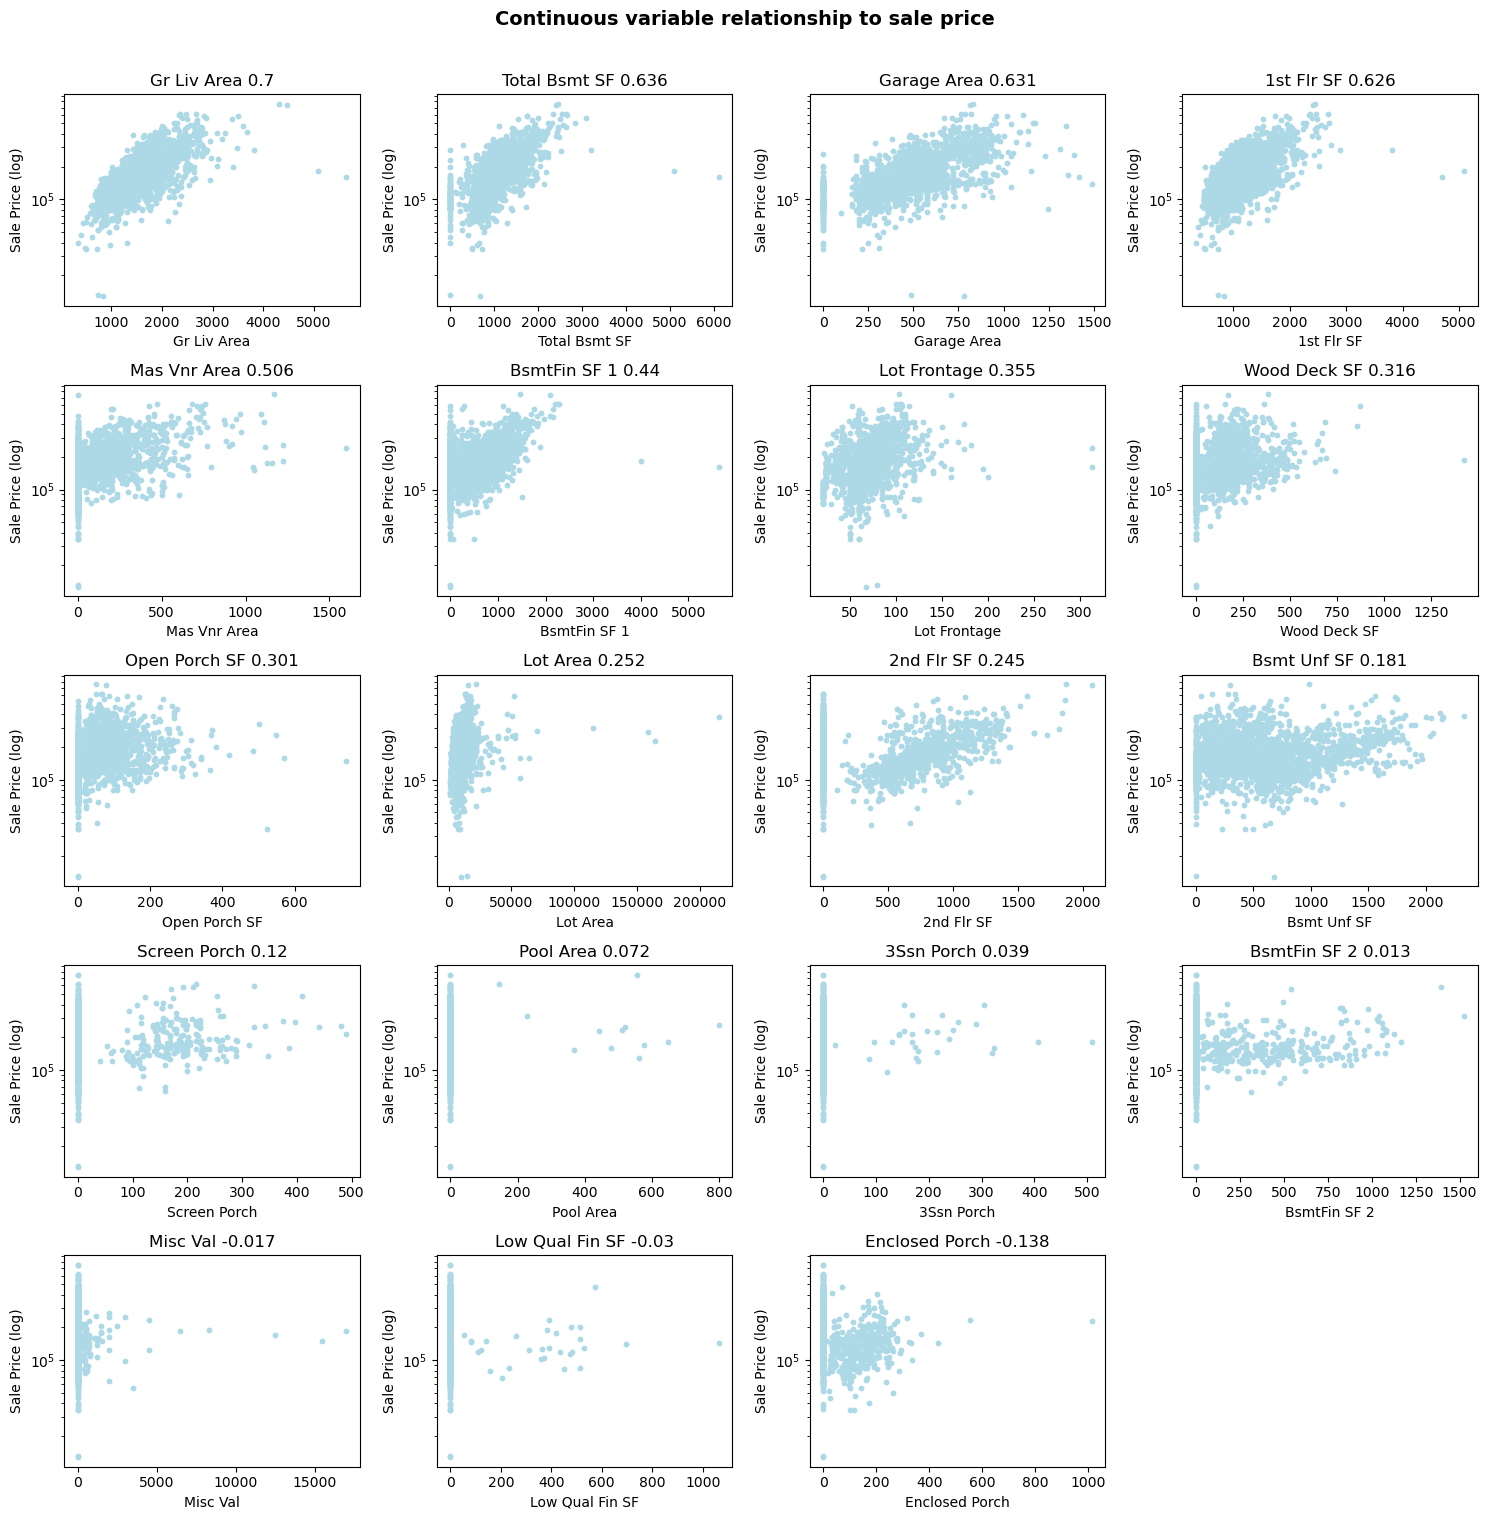

In [31]:
# Scatter plots for the continuous columns 
import math

# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(cont_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
axes = axes.flatten()

for col, i in zip(correlations_cont.index, range(len(correlations_cont.index))):
        axes[i].scatter(data[col], data["SalePrice"], s=10, color="lightblue")
        axes[i].set_title(str(col) + " " + str(round(correlations_cont[col], 3)))
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Sale Price (log)")
        axes[i].set_yscale("log")

# Remove unused subplots
for j in range(len(cont_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Continuous variable relationship to sale price", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

Based on these plots, we can already make the decision to remove some of the variables from the model, as they do not seem to hold predictive power. Indeed, none of these variables seem to be correlated to the sale price. 

The variables that we could remove are: 
- Low Qual Fin SF
- Misc Val
- BsmtFin SF 2
- Bsmt Unf SF

The variables **Low Qual Fin SF** and **Misc Val** are removed because they have very few non-zero observations and show little relationship with the sale price.

The two basement surface area variables are removed because they show little relationship to the sale price and the information they contain should already be contained in the **Total Bsmt SF** variable. Indeed, the Total Basement SF should be equal to BsmtFin SF1 + BsmtFin SF2 + Bsmt Unf SF. Out of these four variables, I will thus choose to only keep the **Total Bsmt SF** and the **BsmtFin SF 1** variables. 

For now, I have made the decision to keep all of the **Porch** variables, as there could be an effect when they are combined into a single variable (we can have a look at this in the feature engineering section). 

Interestingly, we observe that there are a lot of values set to 0 for some of the variables, we will look into this in more detail further on. 

In [32]:
df = df.drop(["BsmtFin SF 2", "Bsmt Unf SF", "Low Qual Fin SF", "Misc Val"], axis=1)
cont_col = [column for column in cont_col if column not in ("BsmtFin SF 2", "Bsmt Unf SF", "Low Qual Fin SF", "Misc Val")]

feat_del.extend(["BsmtFin SF 2", "Bsmt Unf SF", "Low Qual Fin SF", "Misc Val"])

Let's drop these features from the test set as well.

In [33]:
df_test = df_test.drop(["BsmtFin SF 2", "Bsmt Unf SF", "Low Qual Fin SF", "Misc Val"], axis=1)
feat_del_test.extend(["BsmtFin SF 2", "Bsmt Unf SF", "Low Qual Fin SF", "Misc Val"]) 

#### **e) Removing possible colinear features**

Finally, before moving on to the other type of variables, I want to check if some of the features are highly co-linear, and perhaps take the decision to remove some based on this information. To do so, I will start by calculating and visualizing a correlation matrix for all of the features to see if some are highly correlated.

In [34]:
corr_cont = df[cont_col].corr()
corr_cont = corr_cont[(corr_cont > 0.4) & (corr_cont < 1)]
corr_cont = corr_cont.dropna(how="all")
corr_cont = corr_cont.dropna(axis=1, how="all")

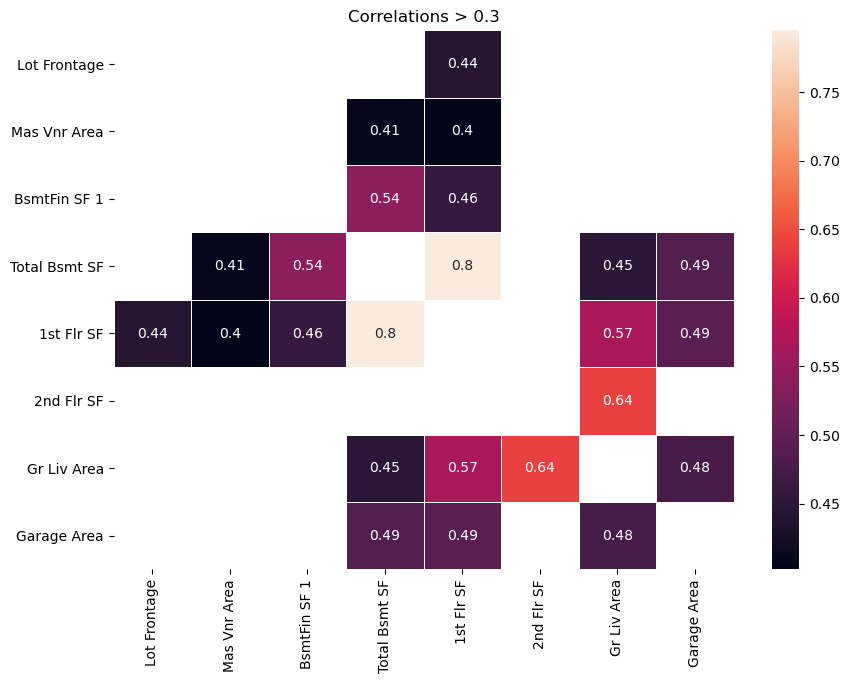

In [35]:
plt.figure(figsize=(10,7))
sns.heatmap(corr_cont, annot=True, linewidths=0.5)
plt.title("Correlations > 0.3")
plt.show()

Based on this analysis, I think it would make sense to investigate the **Gr Liv Area** feature and it's relation to **1st Flr SF** and **2nd Flr SF** as it seems to be strongly correlated to both (0.47 and 0.52). Additionally, the **Lot Frontage** and **Lot Area** also seem correlated, we can also have a look at these variables.

##### **Gr Liv Area**

The Gr Liv Area feature is likely a combination of the 1st Flr SF and 2nd Flr SF features. Let's plot this relationship to understand it better.

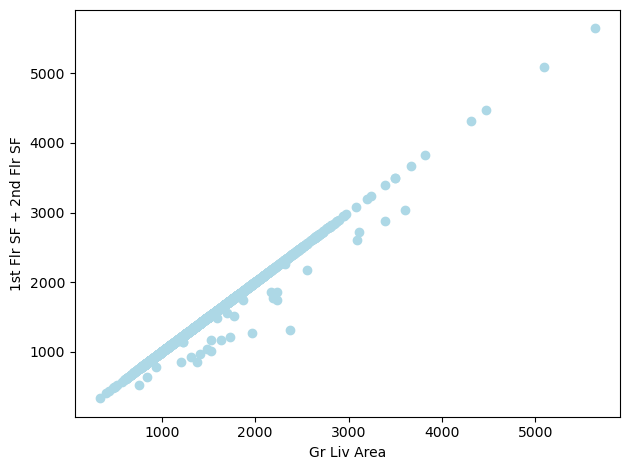

In [36]:
sum_SF = df["1st Flr SF"] +  df["2nd Flr SF"]
plt.scatter(x=df["Gr Liv Area"], y=sum_SF, color="lightblue")
plt.xlabel("Gr Liv Area")
plt.ylabel("1st Flr SF + 2nd Flr SF")
plt.tight_layout()
plt.show()

In [37]:
print(sum_SF.corr(df["Gr Liv Area"]))

0.9954627538157241


We can very clearly see that the **Gr Liv Area** is in most cases equivalent to **1st Flr SF + 2nd Flr SF**. It doesn't make sense to keep all three features. As we saw in our analysis above, Gr Liv Area is more closely correlated to the sale price than the other two features (correlation coefficient of 0.7 for Gr Liv Area vs 0.626 and 0.245 for 1st and 2nd Flr SF respectively. I will thus take the decision to only keep Gr Liv Area as a feature for the model. Additionally, we also saw a very clear correlation between the **Total Bsmt SF** and the **1st Flr SF**, so getting rid of 1st Flr SF also solves this issue. 

In [38]:
df = df.drop(["1st Flr SF", "2nd Flr SF"], axis=1)
df_test = df_test.drop(["1st Flr SF", "2nd Flr SF"], axis=1)
cont_col = [col for col in cont_col if col not in ["1st Flr SF", "2nd Flr SF"]]

feat_del.extend(["1st Flr SF", "2nd Flr SF"])
feat_del_test.extend(["1st Flr SF", "2nd Flr SF"])

##### **Lot Frontage and Lot Area**

These two features both describe the land the house is on. As they seem to be correlated, I would like to investigate their relationship further before deciding if it makes sense to keep both of them or not.

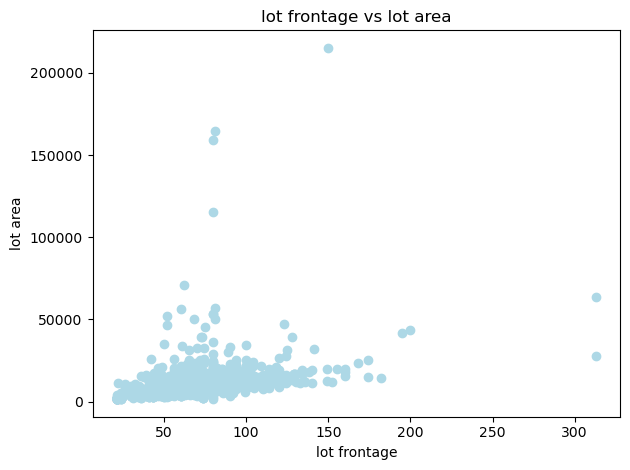

In [39]:
plt.scatter(x=df["Lot Frontage"], y =df["Lot Area"], color="lightblue")
plt.title("lot frontage vs lot area")
plt.xlabel("lot frontage")
plt.ylabel("lot area")
plt.tight_layout()
plt.show()

These features are correlated but do not seem to be colinear (some houses have a very small lot area but an average lot frontage for instance). As they are both correlated with the sale price, I will take the decision to keep them both. 

### **2.2) Exploring the discrete variables**
We will now look at the discrete variables. 


#### **a) Identifying missing values**
Let's start by looking at how much of the data is missing for these columns


In [40]:
# identify missing values
for col in disc_col:
    print("Missing values for", col, ":", df[col].isna().sum(), "(", df[col].isna().sum() / len(df) * 100, "% )") 

Missing values for Year Built : 0 ( 0.0 % )
Missing values for Year Remod/Add : 0 ( 0.0 % )
Missing values for Bsmt Full Bath : 2 ( 0.0823045267489712 % )
Missing values for Bsmt Half Bath : 2 ( 0.0823045267489712 % )
Missing values for Full Bath : 0 ( 0.0 % )
Missing values for Half Bath : 0 ( 0.0 % )
Missing values for Bedroom AbvGr : 0 ( 0.0 % )
Missing values for Kitchen AbvGr : 0 ( 0.0 % )
Missing values for TotRms AbvGrd : 0 ( 0.0 % )
Missing values for Fireplaces : 0 ( 0.0 % )
Missing values for Garage Yr Blt : 138 ( 5.679012345679013 % )
Missing values for Garage Cars : 1 ( 0.0411522633744856 % )
Missing values for Mo Sold : 0 ( 0.0 % )
Missing values for Yr Sold : 0 ( 0.0 % )


We see that the data is in pretty good shape as there are very few missing values. The only feature that is problematic is *Garage Yr Blt*. Let's check this for the test data set as well. 

In [41]:
# identify missing values
for col in disc_col:
    print("Missing values for", col, ":", df_test[col].isna().sum(), "(", df_test[col].isna().sum() / len(df_test) * 100, "% )") 

Missing values for Year Built : 0 ( 0.0 % )
Missing values for Year Remod/Add : 0 ( 0.0 % )
Missing values for Bsmt Full Bath : 0 ( 0.0 % )
Missing values for Bsmt Half Bath : 0 ( 0.0 % )
Missing values for Full Bath : 0 ( 0.0 % )
Missing values for Half Bath : 0 ( 0.0 % )
Missing values for Bedroom AbvGr : 0 ( 0.0 % )
Missing values for Kitchen AbvGr : 0 ( 0.0 % )
Missing values for TotRms AbvGrd : 0 ( 0.0 % )
Missing values for Fireplaces : 0 ( 0.0 % )
Missing values for Garage Yr Blt : 21 ( 4.2 % )
Missing values for Garage Cars : 0 ( 0.0 % )
Missing values for Mo Sold : 0 ( 0.0 % )
Missing values for Yr Sold : 0 ( 0.0 % )


This is very similar to what was observed above, only the feature *Garage Yr Blt* needs adressing.

##### **Addressing the Garage Year Built feature**
We will look at this feature in more detail, is it that this feature is empty when there is no garage ? We can use the Garage Area future to check this (if it is equal to 0, it likely means the houses do not have a garage). 

In [42]:
print("for the training set", ((df["Garage Yr Blt"].isna()) & (df["Garage Area"] == 0)).sum(), "out of", df["Garage Yr Blt"].isna().sum(), "values are missing in the feature *Garage Year Built* since there isn't a garage")
print("for the test set", ((df_test["Garage Yr Blt"].isna()) & (df_test["Garage Area"] == 0)).sum(), "out of", df_test["Garage Yr Blt"].isna().sum(), "values are missing in the feature *Garage Year Built* since there isn't a garage")

for the training set 137 out of 138 values are missing in the feature *Garage Year Built* since there isn't a garage
for the test set 2 out of 21 values are missing in the feature *Garage Year Built* since there isn't a garage


It looks like indeed, for the training set, most of the garage year built don't contain a value (a year) as these houses don't have a garage! The situation seems to be different for the test set, where the reason the garage year built is missing seems to be different. 

We now need to decide what would be the best way to deal with this missing data. 

One thing we could think about is how much information does the feature garage year built contain. In how many cases was the garage actually built on a different year than the house ? If this is minimal, then all of the information of this feature is already contained in the feature "Year Built" and "Garage Area".

We can investigate this by looking at the correlation between "Garage Yr Blt" and "Year Built", as well as the correlation between "Garage Yr Blt" and "SalePrice"

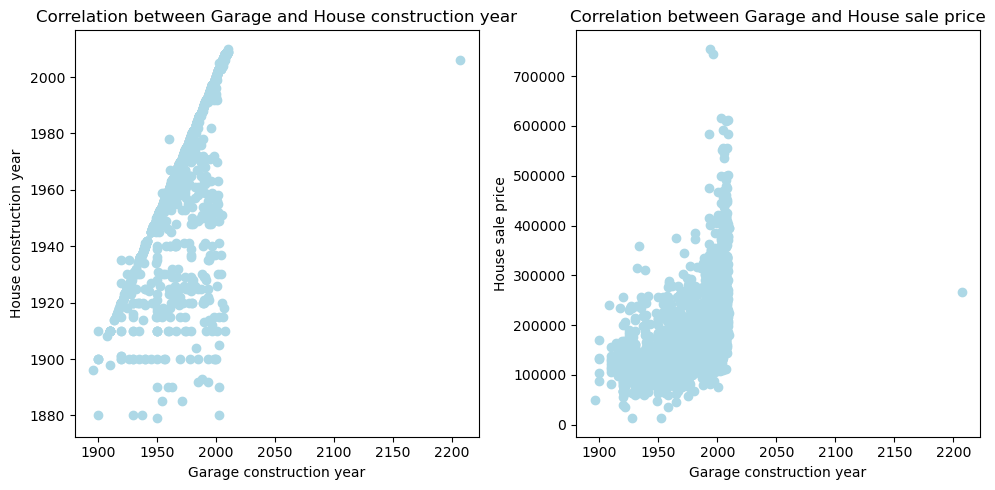

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].scatter(x=df["Garage Yr Blt"], y=df["Year Built"], color="lightblue")
axes[0].set_title("Correlation between Garage and House construction year")
axes[0].set_xlabel("Garage construction year")
axes[0].set_ylabel("House construction year")

axes[1].scatter(x=df["Garage Yr Blt"], y=df["SalePrice"], color="lightblue")
axes[1].set_title("Correlation between Garage and House sale price")
axes[1].set_xlabel("Garage construction year")
axes[1].set_ylabel("House sale price")

plt.tight_layout()
plt.show()

In [44]:
print("Percentage of houses where the garage and the house construction date differ:", (df["Garage Yr Blt"] != df["Year Built"]).sum() / df.shape[0])

Percentage of houses where the garage and the house construction date differ: 0.23909465020576132


We see that our previous theory was actually wrong, a big proportion (a quarter) of the entries have a different construction year for the garage and for the house. We can also see on the scatter plots that the feature does seem to contribute to explaining house sale price, so we need to find a way to adress the missing values. One of the option would be to replace the missing value with a 0 for the houses that don't have a garage, and replace the missing value by the construction year of the house for the houses that do have a garage. Let's do this for both the training and the test set. 

In [45]:
# Training set
df.loc[df["Garage Yr Blt"].isna() & (df["Garage Area"] > 0), "Garage Yr Blt"] = df.loc[df["Garage Yr Blt"].isna() & (df["Garage Area"] > 0), "Year Built"]
df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(0)

# Test set
df_test.loc[df_test["Garage Yr Blt"].isna() & (df_test["Garage Area"] > 0), "Garage Yr Blt"] = df_test.loc[df_test["Garage Yr Blt"].isna() & (df_test["Garage Area"] > 0), "Year Built"]
df_test["Garage Yr Blt"] = df_test["Garage Yr Blt"].fillna(0)

##### **Addressing the other features with missing values**

Let's now have a look at the other features with missing values in the training set. (In the test set, there were no other features with missing values to address).

For the features Bsmt Full Bath and Bsmt Half Bath, we can fill the missing value with a 0 (assuming there isn't a full or half bathroom in the basement for these houses). For the Garage Cars, we can have a look if that house has a garage (by using the garage area), and if it does, we can use the median of that feature to fill the missing value. 

In [46]:
df["Bsmt Full Bath"].fillna(0, inplace=True)
df["Bsmt Half Bath"].fillna(0, inplace=True)

In [47]:
df.loc[df["Garage Cars"].isna(), "Garage Area"]

1565    0.0
Name: Garage Area, dtype: float64

We see that this house doesn't have a garage (the Garage Area is 0). We can thus fill in the missing value with a 0 as well!

In [48]:
df["Garage Cars"].fillna(0, inplace=True)

In [49]:
df[disc_col].isna().sum()

Year Built        0
Year Remod/Add    0
Bsmt Full Bath    0
Bsmt Half Bath    0
Full Bath         0
Half Bath         0
Bedroom AbvGr     0
Kitchen AbvGr     0
TotRms AbvGrd     0
Fireplaces        0
Garage Yr Blt     0
Garage Cars       0
Mo Sold           0
Yr Sold           0
dtype: int64

We see that our data now has no more missing values, our data cleaning strategy worked!

#### **b) Identifying data type inconsistencies**

As a sanity check, let's make sure all of the features contain numerical values

In [50]:
df[disc_col].dtypes

Year Built          int64
Year Remod/Add      int64
Bsmt Full Bath    float64
Bsmt Half Bath    float64
Full Bath           int64
Half Bath           int64
Bedroom AbvGr       int64
Kitchen AbvGr       int64
TotRms AbvGrd       int64
Fireplaces          int64
Garage Yr Blt     float64
Garage Cars       float64
Mo Sold             int64
Yr Sold             int64
dtype: object

In [51]:
df_test[disc_col].dtypes

Year Built          int64
Year Remod/Add      int64
Bsmt Full Bath    float64
Bsmt Half Bath    float64
Full Bath           int64
Half Bath           int64
Bedroom AbvGr       int64
Kitchen AbvGr       int64
TotRms AbvGrd       int64
Fireplaces          int64
Garage Yr Blt     float64
Garage Cars       float64
Mo Sold             int64
Yr Sold             int64
dtype: object

#### **c) Identifying incorrect values**

Now that our data does not contain missing values anymore, we can have a look at the presence of any incorrect values. 

Here is a list of things that would not be possible:
- Garage or House year of construction after 2011 (when the dataset was made)
- Garage built earlier than house (unlikely)
- Year sold not between 2000 and 2011
- Month sold not between January and December (1 and 12)
- Year remodelled after 2010
- Year remodelled before house construction year
- Total Rooms above ground smaller than total Bedrooms + Kitchen above ground
- Total Number of Kitchens < 0
- Total Number of Bathrooms above ground < 0
- Total Number of Bedrooms above ground < 0

Let's adress these one by one and see if they occur in our data set.

In [52]:
print("Impossible house construction date:", (df["Year Built"] > 2011).sum())
print("Impossible garage construction date:", (df["Garage Yr Blt"] > 2011).sum())
print("Garage built before house:", ((df["Garage Yr Blt"] < df["Year Built"]) & (df["Garage Yr Blt"] != 0)).sum())
print("Impossible month sold:", (~df["Mo Sold"].isin(range(1, 13))).sum())
print("Impossible year sold:", (~df["Yr Sold"].isin(range(2000, 2011))).sum())
print("Impossible remodelling date:", (df["Year Remod/Add"] > 2011).sum())
print("Remodelled before construction:", (df["Year Remod/Add"] < df["Year Built"]).sum())
print("Less than 1 Kitchen:", (df["Kitchen AbvGr"] < 1).sum())
print("Less than 1 Bedroom:", (df["Bedroom AbvGr"] < 1).sum())
print("Less than 1 Bathroom:", ((df["Full Bath"] + 0.5*df["Half Bath"]) < 1).sum())

Impossible house construction date: 0
Impossible garage construction date: 1
Garage built before house: 16
Impossible month sold: 0
Impossible year sold: 0
Impossible remodelling date: 0
Remodelled before construction: 0
Less than 1 Kitchen: 2
Less than 1 Bedroom: 8
Less than 1 Bathroom: 8


let's check this for the test set as well.

In [53]:
print("Impossible house construction date:", (df_test["Year Built"] > 2011).sum())
print("Impossible garage construction date:", (df_test["Garage Yr Blt"] > 2011).sum())
print("Garage built before house:", ((df_test["Garage Yr Blt"] < df_test["Year Built"]) & (df_test["Garage Yr Blt"] != 0)).sum())
print("Impossible month sold:", (~df_test["Mo Sold"].isin(range(1, 13))).sum())
print("Impossible year sold:", (~df_test["Yr Sold"].isin(range(2000, 2011))).sum())
print("Impossible remodelling date:", (df_test["Year Remod/Add"] > 2011).sum())
print("Remodelled before construction:", (df_test["Year Remod/Add"] < df_test["Year Built"]).sum())
print("Less than 1 Kitchen:", (df_test["Kitchen AbvGr"] < 1).sum())
print("Less than 1 Bedroom:", (df_test["Bedroom AbvGr"] < 1).sum())
print("Less than 1 Bathroom:", ((df_test["Full Bath"] + 0.5*df_test["Half Bath"]) < 1).sum())

Impossible house construction date: 0
Impossible garage construction date: 0
Garage built before house: 2
Impossible month sold: 0
Impossible year sold: 0
Impossible remodelling date: 0
Remodelled before construction: 1
Less than 1 Kitchen: 1
Less than 1 Bedroom: 0
Less than 1 Bathroom: 0


It seems that for the **training** and the **test sets**, we need to have a closer look at the garage construction dates (one seems wrong as it is after 2011, and others seem unlikely as it would mean that the garage existed before the house). We should also have a look at the houses with less than 1 Kitchen, less than 1 Bedroom or less than 1 Bathroom.

For the test set, there is also an error in the house remodelling date, we should also address this.

##### **Garage Construction dates**

In [54]:
df.loc[df["Garage Yr Blt"] > 2011, "Garage Yr Blt"]

2219    2207.0
Name: Garage Yr Blt, dtype: float64

This is clearly an error, we should remove this entry

In [55]:
df = df[df["Garage Yr Blt"] < 2011]

Now let's have a look at the entries where the garages existed before the house

In [56]:
df.loc[(df["Garage Yr Blt"] < df["Year Built"]) & (df["Garage Yr Blt"] != 0), ("Garage Yr Blt", "Year Built")]

,Garage Yr Blt,Year Built
140,1962.0,1963
154,1926.0,1935
330,1960.0,1978
414,1920.0,1927
476,1949.0,1950
1029,1954.0,1959
1281,1920.0,1935
1316,1956.0,1959
1464,2005.0,2006
1474,2005.0,2006


These values all seem unlikely to me. Let's replace the garage year built with the house year built so that it is consistent. 

In [57]:
df.loc[(df["Garage Yr Blt"] < df["Year Built"]) & (df["Garage Yr Blt"] != 0), "Garage Yr Blt"] = df.loc[(df["Garage Yr Blt"] < df["Year Built"]) & (df["Garage Yr Blt"] != 0), "Year Built"]
print("Garage built before house:", ((df["Garage Yr Blt"] < df["Year Built"]) & (df["Garage Yr Blt"] != 0)).sum())

Garage built before house: 0


Let's do this for the test set as well.

In [58]:
df_test.loc[(df_test["Garage Yr Blt"] < df_test["Year Built"]) & (df_test["Garage Yr Blt"] != 0), "Garage Yr Blt"] = df_test.loc[(df_test["Garage Yr Blt"] < df_test["Year Built"]) & (df_test["Garage Yr Blt"] != 0), "Year Built"]
print("Garage built before house:", ((df_test["Garage Yr Blt"] < df_test["Year Built"]) & (df_test["Garage Yr Blt"] != 0)).sum())

Garage built before house: 0


##### **Number of Kitchens / Bedrooms / Bathrooms**

Let's assume that a normal house should have at least 1 Kitchen, 1 Bathroom and 1 Bedroom. Let's remove all of the entries where this is not the case in the training set. I will not remove these entries from the test set, as it is used to evaluate the model on "real world" data and we don't want to artificially increase model performance.

In [59]:
df = df[df["Kitchen AbvGr"] > 0]
df = df[df["Bedroom AbvGr"] > 0]
df = df[(df["Full Bath"] + 0.5*df["Half Bath"]) > 0]

##### **House remodelling date**
Good. Now let's have a look at the entry in the **test** set that has a remodelling date before the house build date.

In [60]:
df_test.loc[df_test["Year Remod/Add"] < df_test["Year Built"], ("Year Remod/Add", "Year Built")]

,Year Remod/Add,Year Built
182,2001,2002


This is likely a mistake. Let's replace this entry with the year built. 

In [61]:
df_test.loc[df_test["Year Remod/Add"] < df_test["Year Built"], "Year Remod/Add"] = df_test.loc[df_test["Year Remod/Add"] < df_test["Year Built"], "Year Built"]

#### **d) Removing features with low correlation to Sale Price**

As done for the continuous features, we can calculate the correlation between each of the discrete features and the sale price and see if some features don't correlate at all with the sale price. We can also plot the data to have a better understanding of the relationship with the sale price. Based on this information, we can then decide which columns we would like to keep for our model.

Let's first start by calculating the correlation

In [62]:
# Correlation
correlations_disc = df[disc_col + ["SalePrice"]].corr()["SalePrice"]
correlations_disc = correlations_disc.sort_values(ascending=False)
correlations_disc = correlations_disc.drop("SalePrice")
correlations_disc

Garage Cars       0.643288
Year Built        0.560412
Full Bath         0.547775
Year Remod/Add    0.528621
Fireplaces        0.490367
TotRms AbvGrd     0.487550
Half Bath         0.279485
Bsmt Full Bath    0.279366
Garage Yr Blt     0.255226
Bedroom AbvGr     0.141741
Mo Sold           0.034831
Bsmt Half Bath   -0.022305
Yr Sold          -0.027101
Kitchen AbvGr    -0.122549
Name: SalePrice, dtype: float64

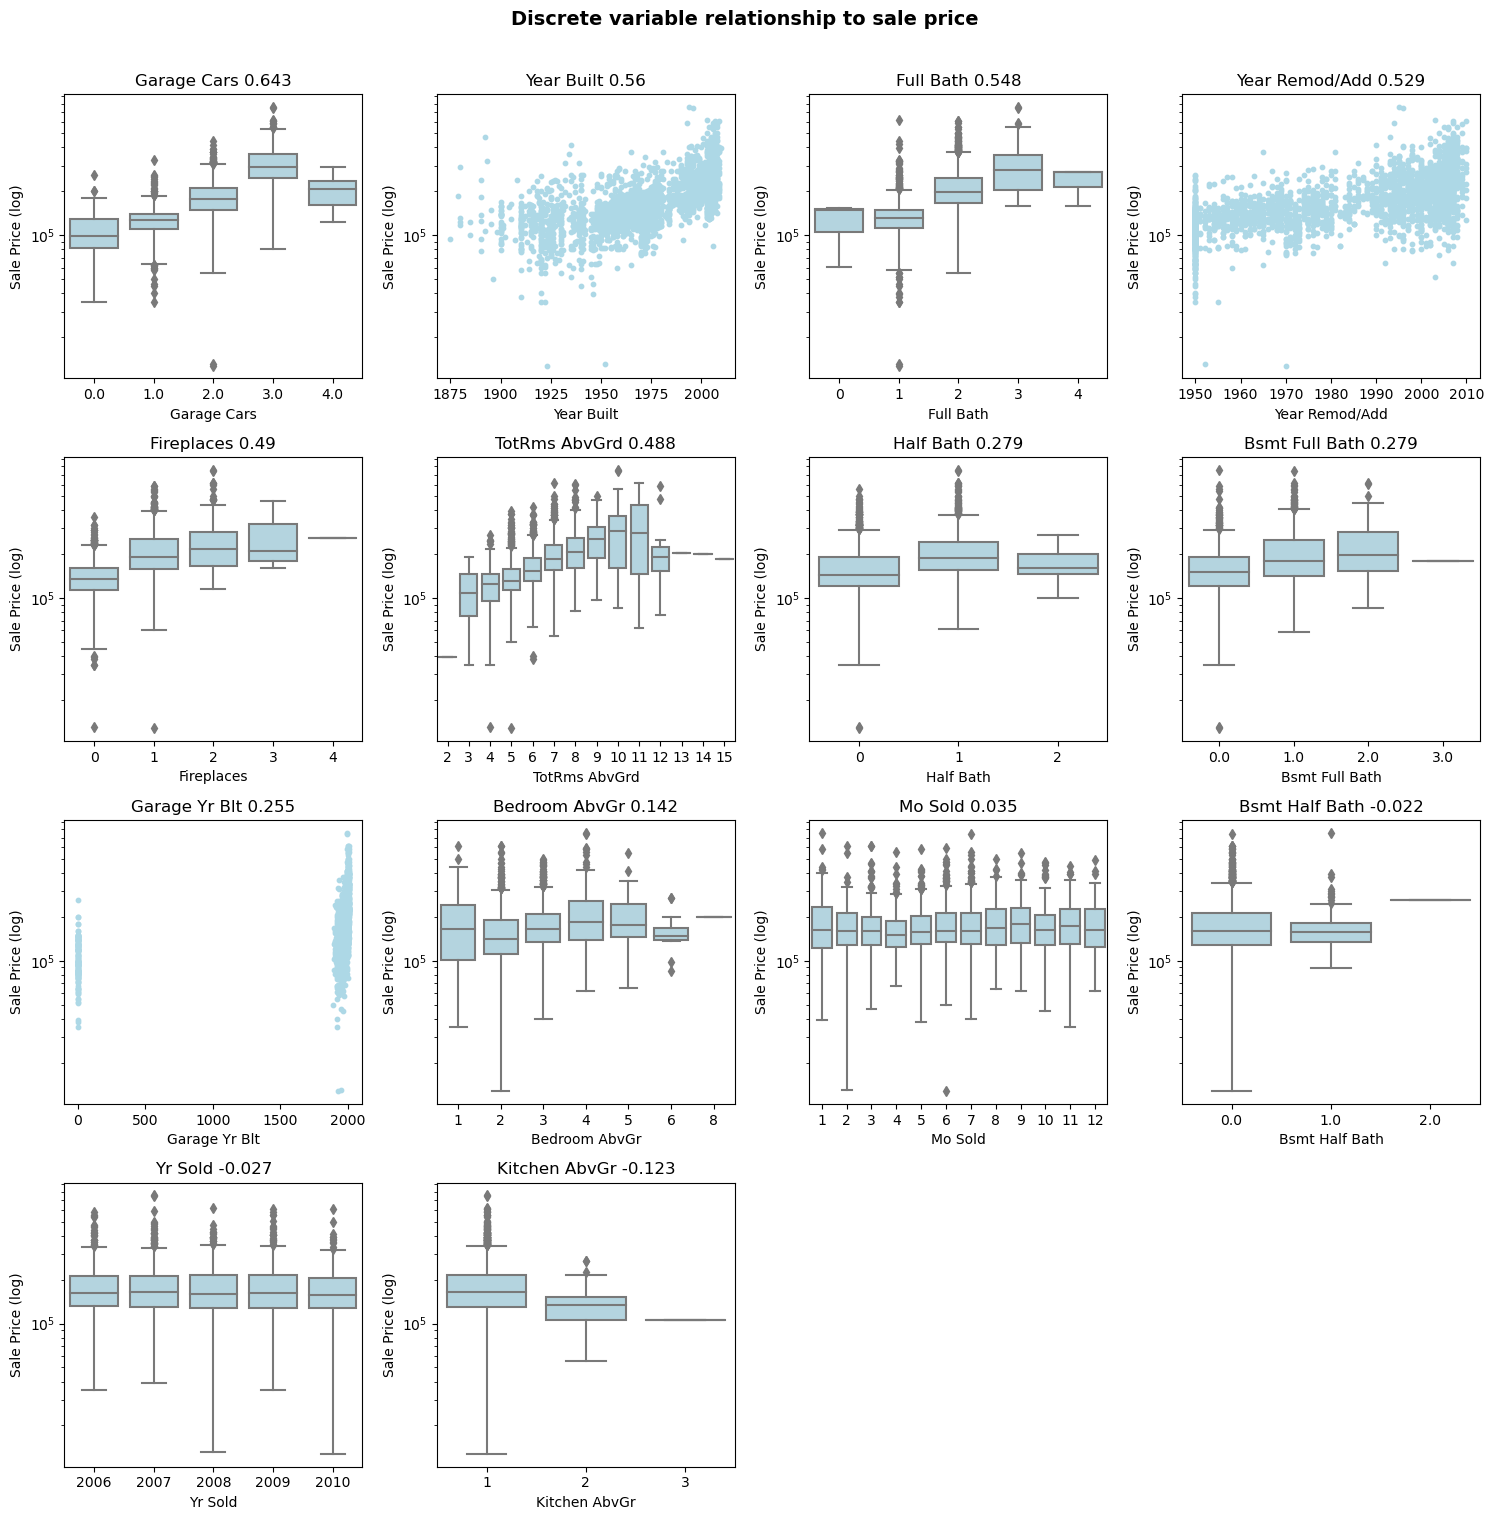

In [63]:
# Scatter and box plots for the discrete columns 
import math

# compute the number of rows and columns for the subplot
n_col = 4
n_rows = math.ceil(len(disc_col) / n_col)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
axes = axes.flatten()

for col, i in zip(correlations_disc.index, range(len(disc_col))):
        if col in ("Year Built", "Year Remod/Add", "Garage Yr Blt"):
            axes[i].scatter(df[col], df["SalePrice"], s=10, color="lightblue")
        else:
            sns.boxplot(data=df, x=col, y="SalePrice", ax=axes[i], color="lightblue")
        axes[i].set_title(str(col) + " " + str(round(correlations_disc[col], 3)))
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Sale Price (log)")
        axes[i].set_yscale("log")

# Remove unused subplots
for j in range(len(disc_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Discrete variable relationship to sale price", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

For some of these Features, the correlation should to be taken with a grain of salt: 
- Garage Yr Built: this feature has a lot of 0s that influence the correlation analysis
- Several features have very low number of values possible (Such as Kitchen above ground or Bsmt Half Bath), here as well the correlation may not be very indicative. 
- For features such as Month and Year sold, a correlation might not be able to show fluctuations (or non linear relationships) in the data. 

However, when looking at both the correlation and the plots, we observe that some features clearly do not seem to be related to the sale price and could be removed from our analysis. 

The features that I will remove are:
- Yr Sold
- Mo Sold

I will not remove the "Bsmt Half Bath" feature even though it is clearly not correlated to the sale price, as I want to keep the option to create an new feature in the **Feature engineering** section of this project combining the information from all bathrooms.

In [64]:
df = df.drop(["Yr Sold", "Mo Sold"], axis=1)

# update the feature list
disc_col = [col for col in disc_col if col not in ("Yr Sold", "Mo Sold")]

feat_del.extend(["Yr Sold", "Mo Sold"])

In [65]:
df_test = df_test.drop(["Yr Sold", "Mo Sold"], axis=1)
feat_del_test.extend(["Yr Sold", "Mo Sold"])

#### **e) Removing possible colinear features**

As for the continuous variables, let's calculate the correlations between the discrete variables to see if some are closely correlated to each other and thus don't add much value to our model


In [66]:
corr_disc = df[disc_col].corr()
corr_disc = corr_disc[(corr_disc > 0.3) & (corr_disc < 1)].dropna(how="all")
corr_disc = corr_disc.dropna(axis=1, how="all")

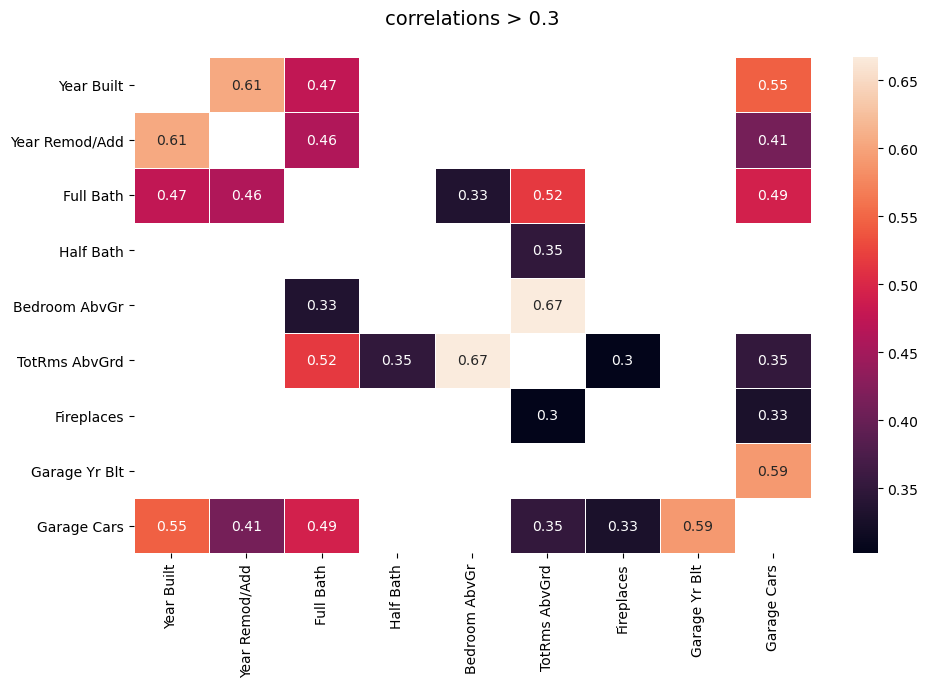

In [67]:
plt.figure(figsize=(10,7))
sns.heatmap(corr_disc, annot=True, linewidths=0.5)
plt.title("correlations > 0.3", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

This is an interesting graph. Some features correlate together that I wasn't expecting (such as the year built and the number of garage car spaces). For the purpose of looking at possible colinear features, we can have a look at the TotRms AbvGrd feature and its relation to Full Bath, Half Bath, Kitchen AbgGr and Bedroom AbvGr. From the documentation, we can assume that the TotRms AvGrd corresponds to the sum of the Bedroom and Kitchen. Let's plot their relationship.

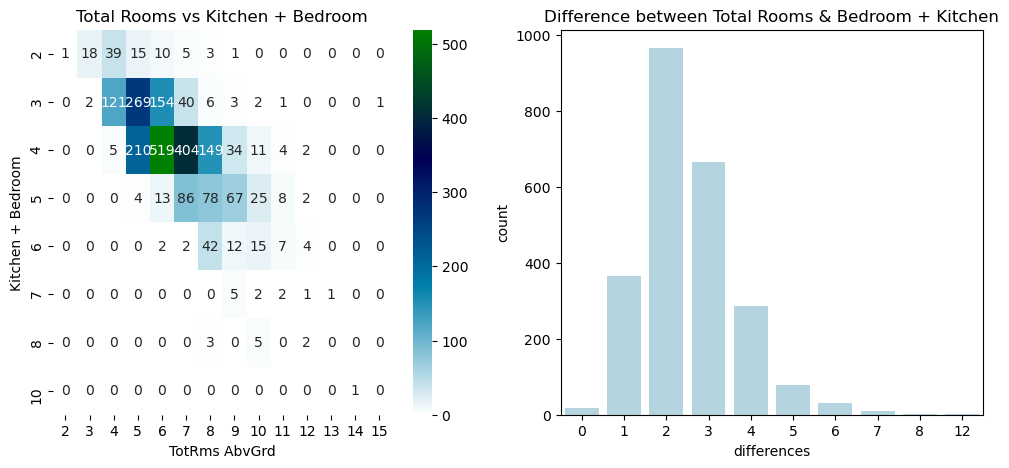

In [68]:
sum_rooms = df["Kitchen AbvGr"] + df["Bedroom AbvGr"]
diff = df["TotRms AbvGrd"] - sum_rooms
pivot = pd.crosstab(sum_rooms, df["TotRms AbvGrd"])

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="ocean_r", ax=axes[0])
axes[0].set_xlabel("TotRms AbvGrd")
axes[0].set_ylabel("Kitchen + Bedroom")
axes[0].set_title("Total Rooms vs Kitchen + Bedroom")

sns.countplot(x=diff, color="lightblue", ax=axes[1])
axes[1].set_xlabel("differences")
axes[1].set_title("Difference between Total Rooms & Bedroom + Kitchen")

plt.show()

From these graphs, we clearly see that even though these features are correlated, they are not colinear as their difference varies. Let's thus keep them in our data set for now.

### **2.3) Exploring the nominal variables**
We will now look at the nominal variables. 

#### **a) Identifying missing values**
Let's start by looking at how much of the data is missing for the nominal features.

In [69]:
# identify missing values
for col in nom_col:
    print("Missing values for", col, ":", df[col].isna().sum(), "(", df[col].isna().sum() / len(df) * 100, "% )")

Missing values for MS SubClass : 0 ( 0.0 % )
Missing values for MS Zoning : 0 ( 0.0 % )
Missing values for Street : 0 ( 0.0 % )
Missing values for Alley : 2255 ( 93.25889164598841 % )
Missing values for Land Contour : 0 ( 0.0 % )
Missing values for Lot Config : 0 ( 0.0 % )
Missing values for Neighborhood : 0 ( 0.0 % )
Missing values for Condition 1 : 0 ( 0.0 % )
Missing values for Condition 2 : 0 ( 0.0 % )
Missing values for Bldg Type : 0 ( 0.0 % )
Missing values for House Style : 0 ( 0.0 % )
Missing values for Roof Style : 0 ( 0.0 % )
Missing values for Roof Matl : 0 ( 0.0 % )
Missing values for Exterior 1st : 0 ( 0.0 % )
Missing values for Exterior 2nd : 0 ( 0.0 % )
Missing values for Mas Vnr Type : 19 ( 0.7857733664185277 % )
Missing values for Foundation : 0 ( 0.0 % )
Missing values for Heating : 0 ( 0.0 % )
Missing values for Central Air : 0 ( 0.0 % )
Missing values for Garage Type : 134 ( 5.5417700578990905 % )
Missing values for Misc Feature : 2329 ( 96.31927212572374 % )
Missin

In [70]:
# identify missing values
for col in nom_col:
    print("Missing values for", col, ":", df_test[col].isna().sum(), "(", df_test[col].isna().sum() / len(df_test) * 100, "% )")

Missing values for MS SubClass : 0 ( 0.0 % )
Missing values for MS Zoning : 0 ( 0.0 % )
Missing values for Street : 0 ( 0.0 % )
Missing values for Alley : 465 ( 93.0 % )
Missing values for Land Contour : 0 ( 0.0 % )
Missing values for Lot Config : 0 ( 0.0 % )
Missing values for Neighborhood : 0 ( 0.0 % )
Missing values for Condition 1 : 0 ( 0.0 % )
Missing values for Condition 2 : 0 ( 0.0 % )
Missing values for Bldg Type : 0 ( 0.0 % )
Missing values for House Style : 0 ( 0.0 % )
Missing values for Roof Style : 0 ( 0.0 % )
Missing values for Roof Matl : 0 ( 0.0 % )
Missing values for Exterior 1st : 0 ( 0.0 % )
Missing values for Exterior 2nd : 0 ( 0.0 % )
Missing values for Mas Vnr Type : 3 ( 0.6 % )
Missing values for Foundation : 0 ( 0.0 % )
Missing values for Heating : 0 ( 0.0 % )
Missing values for Central Air : 0 ( 0.0 % )
Missing values for Garage Type : 21 ( 4.2 % )
Missing values for Misc Feature : 484 ( 96.8 % )
Missing values for Sale Type : 0 ( 0.0 % )
Missing values for Sale

There are clearly some features that seem to contain a lot of missing values! In the "Alley" and the "Misc Feature" Variables, at least 90% of the data is missing in the training set for instance. Let's plot these columns and remove these features from our data set if they do not seem to contribute to sale price. 

The other two features that we will look at in more detail are "Garage Type" and "Mas Vnr Type". 

##### **Addressing Misc Feature and Alley**
To fully visualize the data, let's first fill in the missing values with "none"

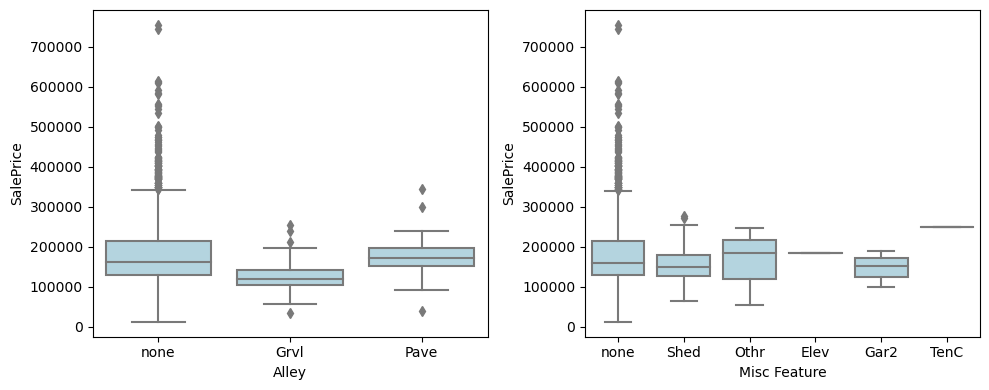

In [71]:
df["Alley"].fillna("none", inplace=True)
df["Misc Feature"].fillna("none", inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.boxplot(data=df, x="Alley", y="SalePrice", ax=axes[0], color="lightblue")
sns.boxplot(data=df, x="Misc Feature", y="SalePrice", ax=axes[1], color="lightblue")

plt.tight_layout()
plt.show()

It does seem like the for both of the features, the different categories have different sale prices. But how many houses does this really concern ? Let's check this using value_counts.

In [72]:
print(df["Alley"].value_counts())
print(df["Alley"].value_counts(normalize=True)*100)

none    2255
Grvl     104
Pave      59
Name: Alley, dtype: int64
none    93.258892
Grvl     4.301075
Pave     2.440033
Name: Alley, dtype: float64


In [73]:
print(df["Misc Feature"].value_counts())
print(df["Misc Feature"].value_counts(normalize=True)*100)

none    2329
Shed      79
Gar2       5
Othr       3
Elev       1
TenC       1
Name: Misc Feature, dtype: int64
none    96.319272
Shed     3.267163
Gar2     0.206782
Othr     0.124069
Elev     0.041356
TenC     0.041356
Name: Misc Feature, dtype: float64


It really seems like very few houses are concerned (especially in the Misc Features column). Let's simply remove these two features, as they likely don'd add much value to our model.

In [74]:
# Removing the two problematic columns
df = df.drop(["Alley", "Misc Feature"], axis=1)
df_test = df_test.drop(["Alley", "Misc Feature"], axis=1)
nom_col = [col for col in nom_col if col not in ("Alley", "Misc Feature")]

##### **Filling the missing values in "Garage Type"**

One hypothesis could be that this feature is empty when the houses don't have a garage. We can check this by looking at the Garage Area feature (if it is 0, the houses don't have a garage). 

In [75]:
print("Training set: percentage of missing values that actually don't have a garage:", ((df["Garage Area"] == 0) & (df["Garage Type"].isna())).sum() / df["Garage Type"].isna().sum() * 100)
print("Test set: percentage of missing values that actually don't have a garage:", ((df_test["Garage Area"] == 0) & (df_test["Garage Type"].isna())).sum() / df_test["Garage Type"].isna().sum() * 100)

Training set: percentage of missing values that actually don't have a garage: 100.0
Test set: percentage of missing values that actually don't have a garage: 9.523809523809524


As we hypothesized, all of the entries in the training set are empty since the houses they correspond to don't have a garage. Let's now investigate what would be the best approach to fill these empty values. 

Let's look more closely at the possible values for this feature. 

In [76]:
print(df["Garage Type"].value_counts())

Attchd     1429
Detchd      648
BuiltIn     147
Basment      28
2Types       22
CarPort      10
Name: Garage Type, dtype: int64


For the training set, I will replace the missing values by the value "NoGrg". For the **test** set, I will replace the missing values by the most frequent value in the **training** set for the houses that do have a garage, and by NoGrg for the houses that do not have a garage.

In [77]:
df.loc[df["Garage Type"].isna(), "Garage Type"] = "NoGrg"
df["Garage Type"].value_counts()

Attchd     1429
Detchd      648
BuiltIn     147
NoGrg       134
Basment      28
2Types       22
CarPort      10
Name: Garage Type, dtype: int64

In [78]:
# Houses that don't have a garage
df_test.loc[(df_test["Garage Area"] == 0) & (df_test["Garage Type"].isna()), "Garage Type"] = 0

In [79]:
# The other houses
df_test["Garage Type"].fillna(df["Garage Type"].mode()[0], inplace=True)

##### **Filling the missing values in "Mas Vnr Type"**

We can take a similar approach for this feature. It is possible that the missing values correspond to houses without masonry veneer. Let's check this and if it is the case, let's fill in the missing values with "NoMasVnr"

In [80]:
print("Training set: Percentage of missing values that actually don't have a Masonry Veneer:", ((df["Mas Vnr Area"] == 0) & (df["Mas Vnr Type"].isna())).sum() / df["Mas Vnr Type"].isna().sum() * 100)
print("Test set: Percentage of missing values that actually don't have a Masonry Veneer:", ((df_test["Mas Vnr Area"] == 0) & (df_test["Mas Vnr Type"].isna())).sum() / df_test["Mas Vnr Type"].isna().sum() * 100)

Training set: Percentage of missing values that actually don't have a Masonry Veneer: 100.0
Test set: Percentage of missing values that actually don't have a Masonry Veneer: 100.0


In [81]:
df["Mas Vnr Type"].value_counts()

None       1434
BrkFace     733
Stone       210
BrkCmn       21
CBlock        1
Name: Mas Vnr Type, dtype: int64

In [82]:
# Filling in empty values
df.loc[df["Mas Vnr Type"].isna(), "Mas Vnr Type"] = "NoMasVnr"
df_test.loc[df_test["Mas Vnr Type"].isna(), "Mas Vnr Type"] = "NoMasVnr"
df["Mas Vnr Type"].value_counts()

None        1434
BrkFace      733
Stone        210
BrkCmn        21
NoMasVnr      19
CBlock         1
Name: Mas Vnr Type, dtype: int64

In [83]:
df[nom_col].isna().sum()

MS SubClass       0
MS Zoning         0
Street            0
Land Contour      0
Lot Config        0
Neighborhood      0
Condition 1       0
Condition 2       0
Bldg Type         0
House Style       0
Roof Style        0
Roof Matl         0
Exterior 1st      0
Exterior 2nd      0
Mas Vnr Type      0
Foundation        0
Heating           0
Central Air       0
Garage Type       0
Sale Type         0
Sale Condition    0
dtype: int64

In [84]:
df_test[nom_col].isna().sum()

MS SubClass       0
MS Zoning         0
Street            0
Land Contour      0
Lot Config        0
Neighborhood      0
Condition 1       0
Condition 2       0
Bldg Type         0
House Style       0
Roof Style        0
Roof Matl         0
Exterior 1st      0
Exterior 2nd      0
Mas Vnr Type      0
Foundation        0
Heating           0
Central Air       0
Garage Type       0
Sale Type         0
Sale Condition    0
dtype: int64

Our data cleaning strategy worked! We don't have any missing values in the nominal columns anymore.

#### **b) Removing features with low impact on sale price**

Let's now plot the nominal features to see if there are some that don't seem to have an influence on the sale price. We won't be looking at correlation here since this metric doesn't make sense for nominal features. We will start by making boxplots to investigate the individual features

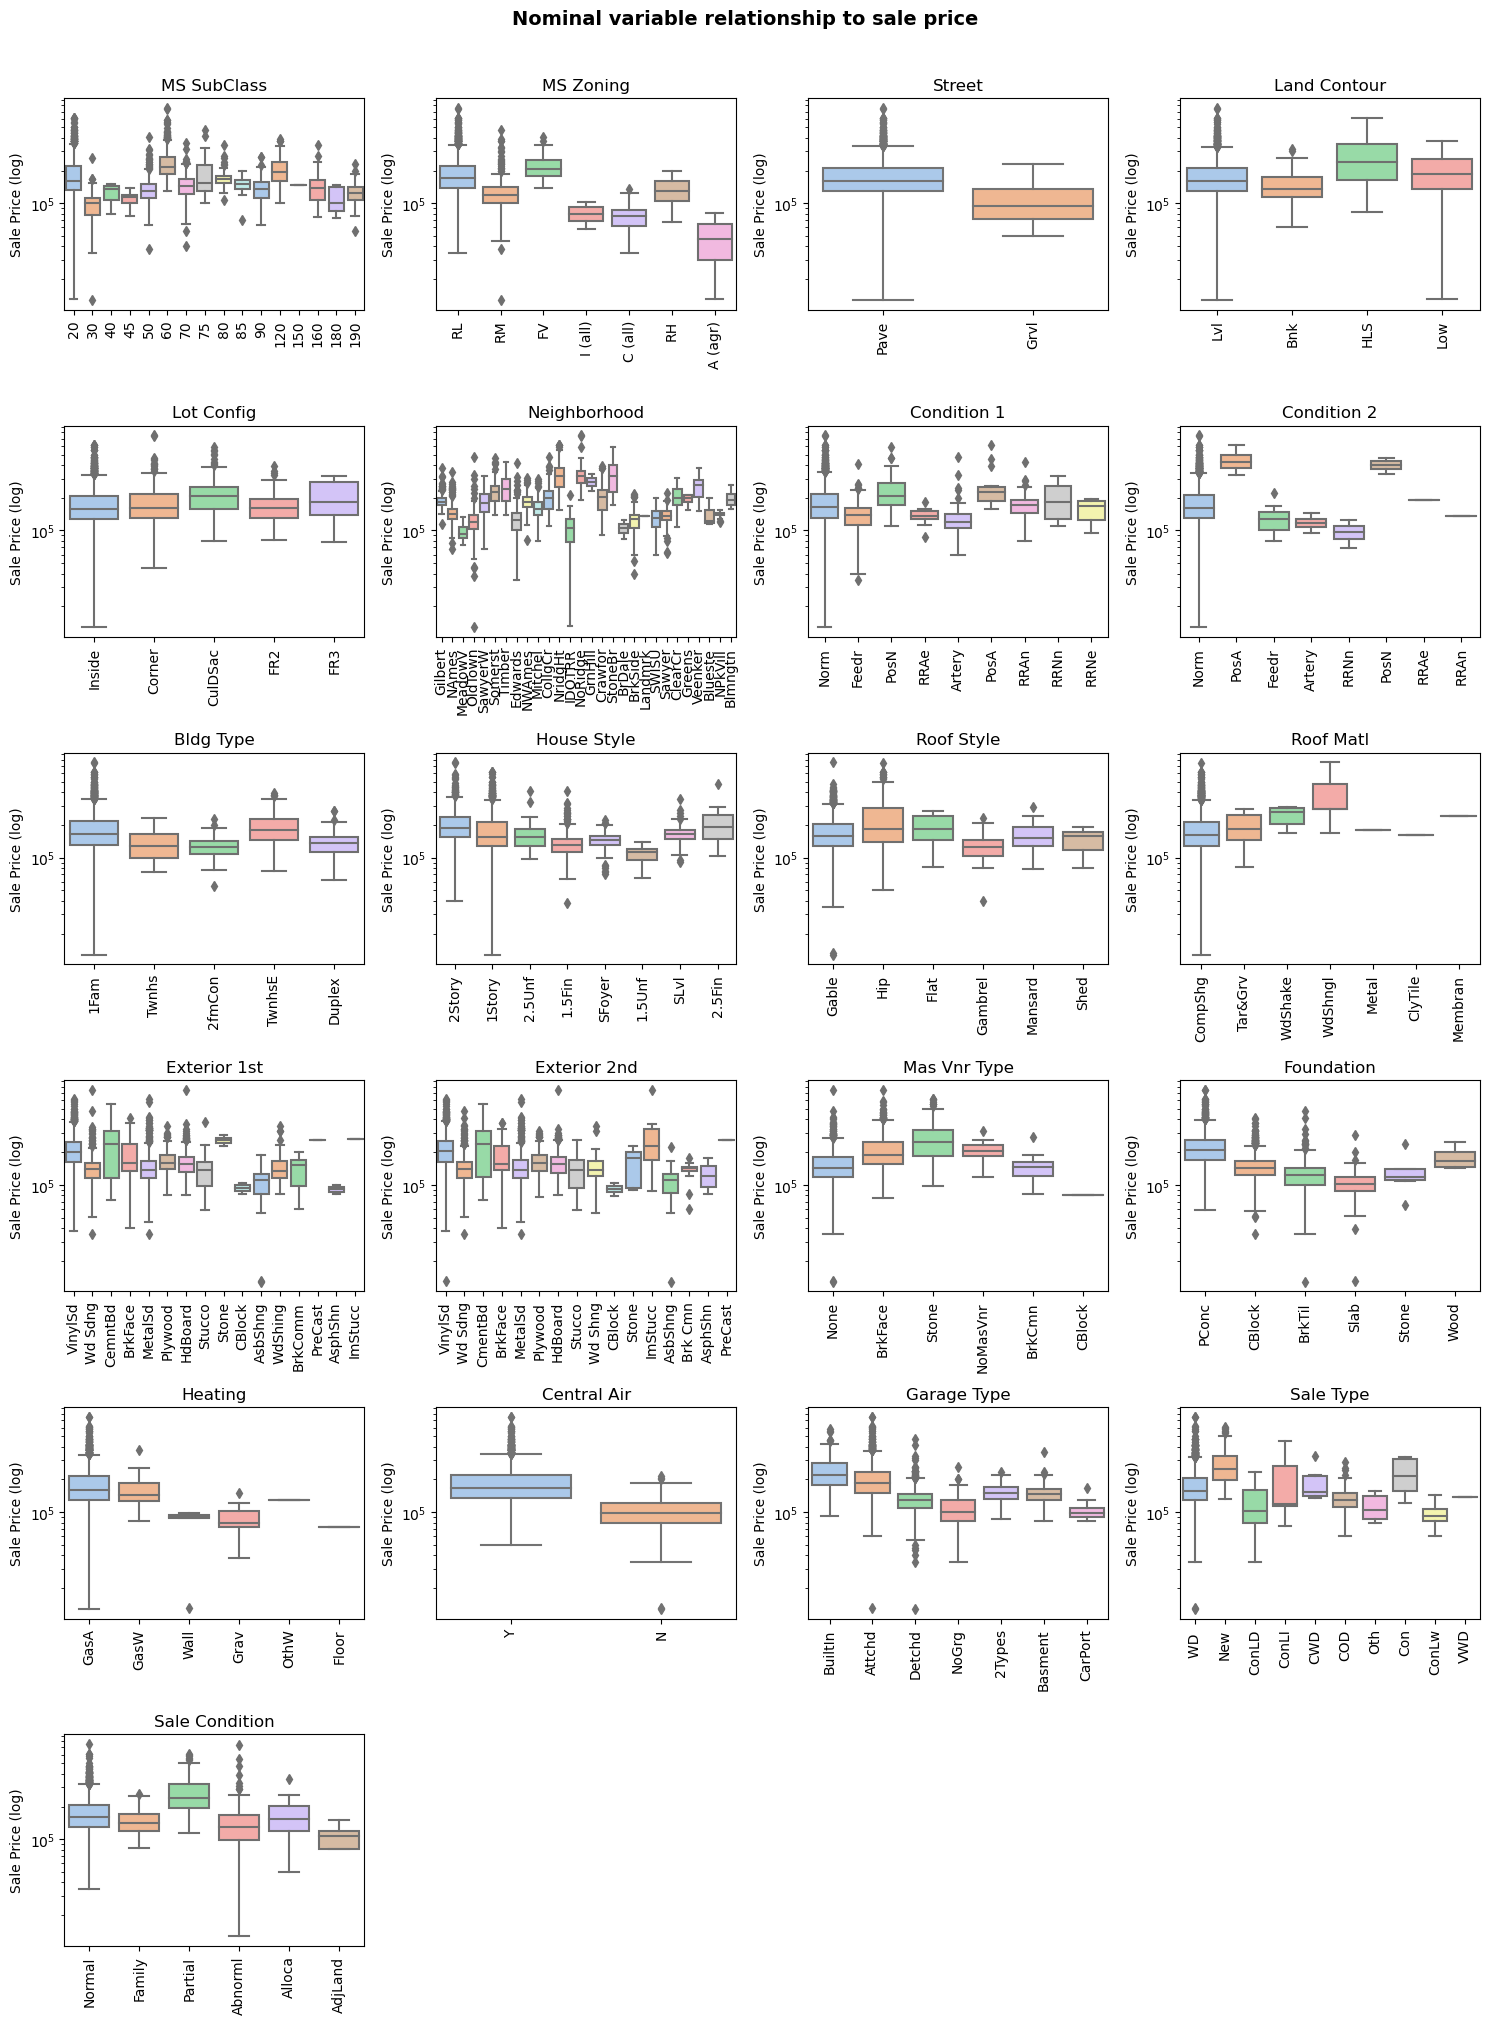

In [85]:
# Boxplots for the nominal columns 
import math

# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(nom_col) / n_col)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.flatten()

for col, i in zip(nom_col, range(len(nom_col))):
        sns.boxplot(data=df, x=col, y="SalePrice", ax=axes[i], palette="pastel")
        axes[i].set_title(col)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Sale Price (log)")
        axes[i].set_yscale("log")
        axes[i].tick_params(axis='x', rotation=90)

# Remove unused subplots
for j in range(len(nom_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Nominal variable relationship to sale price", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

Interestingly, at a first glance, most of these variables seem to influence the sale price (some more drastically than others). An example of a feature that has a strong influence on the sale price is the neighborhood. An example of a feature that does not seem to have an influence on the sale price is the Lot Config feature. Let's remove it. I will take the decision not to remove any other features, as they all seem to have an influence on the sale price.

In [86]:
df = df.drop("Lot Config", axis=1)
df_test = df_test.drop("Lot Config", axis=1)
nom_col = [col for col in nom_col if col not in ("Lot Config")]

feat_del_test.extend(["Lot Config"])
feat_del.extend(["Lot Config"])

### **2.4) Exploring the ordinal features**
We will now look at the ordinal variables. 

#### **a) Identifying missing values**

Let's have a look at the percentage of missing values in the ordinal features. 

In [87]:
# identify missing values
for col in ord_col:
    print("Missing values for", col, ":", df[col].isna().sum(), "(", df[col].isna().sum() / len(df) * 100, "% )")

Missing values for Lot Shape : 0 ( 0.0 % )
Missing values for Utilities : 0 ( 0.0 % )
Missing values for Land Slope : 0 ( 0.0 % )
Missing values for Overall Qual : 0 ( 0.0 % )
Missing values for Overall Cond : 0 ( 0.0 % )
Missing values for Exter Qual : 0 ( 0.0 % )
Missing values for Exter Cond : 0 ( 0.0 % )
Missing values for Bsmt Qual : 71 ( 2.93631100082713 % )
Missing values for Bsmt Cond : 71 ( 2.93631100082713 % )
Missing values for Bsmt Exposure : 74 ( 3.0603804797353185 % )
Missing values for BsmtFin Type 1 : 71 ( 2.93631100082713 % )
Missing values for BsmtFin Type 2 : 72 ( 2.977667493796526 % )
Missing values for Heating QC : 0 ( 0.0 % )
Missing values for Electrical : 1 ( 0.0413564929693962 % )
Missing values for Kitchen Qual : 0 ( 0.0 % )
Missing values for Functional : 0 ( 0.0 % )
Missing values for Fireplace Qu : 1179 ( 48.759305210918114 % )
Missing values for Garage Finish : 136 ( 5.624483043837883 % )
Missing values for Garage Qual : 136 ( 5.624483043837883 % )
Missing

In [88]:
# identify missing values
for col in ord_col:
    print("Missing values for", col, ":", df_test[col].isna().sum(), "(", df_test[col].isna().sum() / len(df_test) * 100, "% )")

Missing values for Lot Shape : 0 ( 0.0 % )
Missing values for Utilities : 0 ( 0.0 % )
Missing values for Land Slope : 0 ( 0.0 % )
Missing values for Overall Qual : 0 ( 0.0 % )
Missing values for Overall Cond : 0 ( 0.0 % )
Missing values for Exter Qual : 0 ( 0.0 % )
Missing values for Exter Cond : 0 ( 0.0 % )
Missing values for Bsmt Qual : 9 ( 1.7999999999999998 % )
Missing values for Bsmt Cond : 9 ( 1.7999999999999998 % )
Missing values for Bsmt Exposure : 9 ( 1.7999999999999998 % )
Missing values for BsmtFin Type 1 : 9 ( 1.7999999999999998 % )
Missing values for BsmtFin Type 2 : 9 ( 1.7999999999999998 % )
Missing values for Heating QC : 0 ( 0.0 % )
Missing values for Electrical : 0 ( 0.0 % )
Missing values for Kitchen Qual : 0 ( 0.0 % )
Missing values for Functional : 0 ( 0.0 % )
Missing values for Fireplace Qu : 236 ( 47.199999999999996 % )
Missing values for Garage Finish : 21 ( 4.2 % )
Missing values for Garage Qual : 21 ( 4.2 % )
Missing values for Garage Cond : 21 ( 4.2 % )
Missi

We immediately see that some features are almost entirely filled with missing values. For instance, the feature "Pool QC" contains 99% of missing values (presumably from houses without a pool). The information if a house has or not a pool is already contained in the feature "Pool Area". We can probably remove this feature alltogether since it is really very empty.

A similar reflexion can be applied to the Feature Fireplace Qu. The feature is partially empty, (because a lot of houses don't have a fireplace), and the information if a house has a fireplace or not is already contained in another variable (number of fireplaces). Let's plot it first to investigate if it influences the sale price. 

Finally, let's also plot the third mainly empty feature (Fence). 

##### **Addressing the mainly empty features**

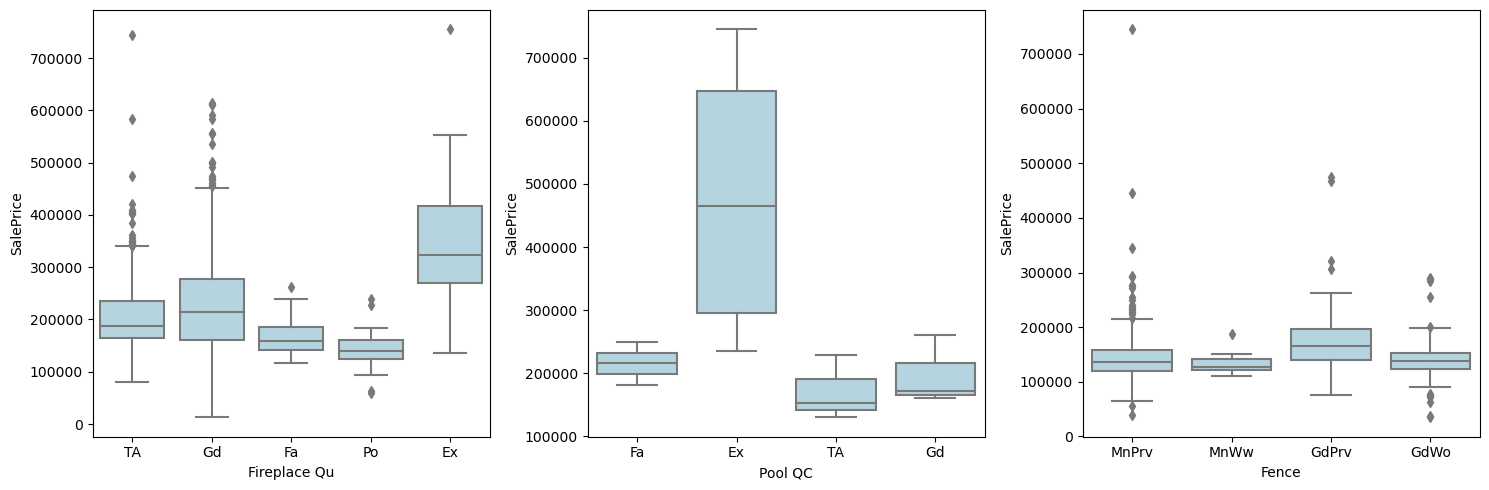

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x="Fireplace Qu", y="SalePrice", ax=axes[0], color="lightblue")
sns.boxplot(data=df, x="Pool QC", y="SalePrice", ax=axes[1], color="lightblue")
sns.boxplot(data=df, x="Fence", y="SalePrice", ax=axes[2], color="lightblue")
plt.tight_layout()
plt.show()

In [90]:
# Value counts
print(df["Fireplace Qu"].value_counts(normalize=True)*100)
print(df["Pool QC"].value_counts(normalize=True)*100)
print(df["Fence"].value_counts(normalize=True)*100)

Gd    49.798224
TA    38.418079
Fa     5.326877
Po     3.389831
Ex     3.066990
Name: Fireplace Qu, dtype: float64
Ex    33.333333
TA    25.000000
Gd    25.000000
Fa    16.666667
Name: Pool QC, dtype: float64
MnPrv    59.016393
GdPrv    19.672131
GdWo     19.262295
MnWw      2.049180
Name: Fence, dtype: float64


From these three plots and the value count information, I have decided to keep the feature Fireplace Qu, but get rid of the feature Fence (it doesn't seem to influence the sale price very much) and of the Feature Pool QC (there are so little houses in each category that it will likely not add much meaningful information in the model). 

In [91]:
df = df.drop(["Pool QC", "Fence"], axis=1)
df_test = df_test.drop(["Pool QC", "Fence"], axis=1)
ord_col = [col for col in ord_col if col not in ("Pool QC", "Fence")]

feat_del_test.extend(["Pool QC", "Fence"])
feat_del.extend(["Pool QC", "Fence"])


print(df.shape)
print(df_test.shape)

(2418, 67)
(500, 66)


We now still need to address the fireplace feature. For this feature, we will first check how many houses don't have a value in this feature because they do not have a fireplace using the *Fireplaces* feature. If the houses do not have a fireplace, I will fill in the missing values with "NoFireplace". If they do have one, I will fill in the missing values with the most common value for this feature in the training data set.

In [92]:
print("training data set")
print(len(df[(df["Fireplace Qu"].isna()) & (df["Fireplaces"] == 0)]) / df["Fireplace Qu"].isna().sum() * 100, "% of the missing values are due to not having a fireplace")

training data set
100.0 % of the missing values are due to not having a fireplace


In [93]:
print("test data set")
print(len(df_test[(df_test["Fireplace Qu"].isna()) & (df_test["Fireplaces"] == 0)]) / df_test["Fireplace Qu"].isna().sum() * 100, "% of the missing values are due to not having a fireplace")

test data set
100.0 % of the missing values are due to not having a fireplace


It seems like all of the values are missing since the house does not have a fireplace. Let's fill in the missing values with "NoFireplace".

In [94]:
df["Fireplace Qu"].fillna("NoFireplace", inplace=True)
df_test["Fireplace Qu"].fillna("NoFireplace", inplace=True)

##### **Adressing the Basement Features**

For the different basement features (Bsmt Qual, Bsmt Cond, Bsmt Exposure, BsmtFin Type 1, BsmtFin Type 2), the empty values could be related to houses that do not have a basement. Let's check this theory by using the feature "Total Bsmt SF" which should be 0 if houses don't have a basement.

If the houses do not have a basement, I will fill in the missing values with "NoBsmt". If they do have one, I will fill in the missing values with the most frequent value in the training data set for this feature.

In [95]:
print("for the training set:")
for col in ("Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"):    
    print(col, ":", len(df[(df[col].isna()) & (df["Total Bsmt SF"] == 0)]) / df[col].isna().sum() * 100, "% of the missing values are due to not having a basement")

for the training set:
Bsmt Qual : 100.0 % of the missing values are due to not having a basement
Bsmt Cond : 100.0 % of the missing values are due to not having a basement
Bsmt Exposure : 95.94594594594594 % of the missing values are due to not having a basement
BsmtFin Type 1 : 100.0 % of the missing values are due to not having a basement
BsmtFin Type 2 : 98.61111111111111 % of the missing values are due to not having a basement


In [96]:
print("for the test set:")
for col in ("Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"):    
    print(col, ":", len(df_test[(df_test[col].isna()) & (df_test["Total Bsmt SF"] == 0)]) / df_test[col].isna().sum() * 100, "% of the missing values are due to not having a basement")

for the test set:
Bsmt Qual : 0.0 % of the missing values are due to not having a basement
Bsmt Cond : 0.0 % of the missing values are due to not having a basement
Bsmt Exposure : 0.0 % of the missing values are due to not having a basement
BsmtFin Type 1 : 0.0 % of the missing values are due to not having a basement
BsmtFin Type 2 : 0.0 % of the missing values are due to not having a basement


Alright, let's fill in all of the instance where the house does not have a basement with "NoBsmt" in the training set.

In [97]:
for col in ("Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"):
    df.loc[(df[col].isna()) & (df["Total Bsmt SF"] == 0), col] = "NoBsmt"
    print(col, ":",  df[col].isna().sum(), "leftover missing values")

Bsmt Qual : 0 leftover missing values
Bsmt Cond : 0 leftover missing values
Bsmt Exposure : 3 leftover missing values
BsmtFin Type 1 : 0 leftover missing values
BsmtFin Type 2 : 1 leftover missing values


Let's now have at the houses that do have a basement, but for which the value isn't given. Let's see what the possible values are for each feature, and replace the missing value with the most frequent feature.

For the **test** set, we will replace the missing value with the most frequent feature in the **training** set.

Let's start by working on the training set, and then on the test set.

In [98]:
df["Bsmt Exposure"].value_counts()

No        1562
Av         344
Gd         230
Mn         208
NoBsmt      71
Name: Bsmt Exposure, dtype: int64

Alright, it seems like most houses have the value "No" for the basement exposure. Let's replace the missing values in the training set by this.

In [99]:
df["Bsmt Exposure"].fillna(df["Bsmt Exposure"].mode()[0], inplace=True)
df["Bsmt Exposure"].isna().sum()

0

Let's do the same for the "Bsmt Fin Type 2" feature.

In [100]:
df["BsmtFin Type 2"].value_counts()

Unf       2055
Rec         84
LwQ         75
NoBsmt      71
BLQ         61
ALQ         45
GLQ         26
Name: BsmtFin Type 2, dtype: int64

Here as well, let's take the most common feature to fill in the missing values.

In [101]:
df["BsmtFin Type 2"].fillna(df["BsmtFin Type 2"].mode()[0], inplace=True)
df["Bsmt Exposure"].isna().sum()

0

Finally, let's apply this logic to the test set.

In [102]:
for col in ("Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"):
    mode_training = df[col].mode()[0]
    df_test[col].fillna(mode_training, inplace=True)

df.loc[:, ("Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2")].isna().sum()

Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     0
BsmtFin Type 1    0
BsmtFin Type 2    0
dtype: int64

##### **Addressing the Garage Features**

We can now apply a similar logic to the Garage features (Garage Finish, Garage Qual and Garage Cond). Let's first check if these values are empty because the house doesn't have a garage. Let's fill these values with 0. Then, let's fill in the other missing values with the mode (the most common value in the training set).

In [103]:
print("Training set:")
for col in ("Garage Finish", "Garage Qual", "Garage Cond"):    
    print(col, ":", len(df[(df[col].isna()) & (df["Garage Area"] == 0)]) / df[col].isna().sum() * 100, "% of the missing values are due to not having a garage")

Training set:
Garage Finish : 99.26470588235294 % of the missing values are due to not having a garage
Garage Qual : 99.26470588235294 % of the missing values are due to not having a garage
Garage Cond : 99.26470588235294 % of the missing values are due to not having a garage


In [104]:
print("Test set:")
for col in ("Garage Finish", "Garage Qual", "Garage Cond"):    
    print(col, ":", len(df_test[(df_test[col].isna()) & (df_test["Garage Area"] == 0)]) / df_test[col].isna().sum() * 100, "% of the missing values are due to not having a garage")

Test set:
Garage Finish : 9.523809523809524 % of the missing values are due to not having a garage
Garage Qual : 9.523809523809524 % of the missing values are due to not having a garage
Garage Cond : 9.523809523809524 % of the missing values are due to not having a garage


Let's fill in the cases where the houses do not have a garage with "NoGrg"

In [105]:
for col in ("Garage Finish", "Garage Qual", "Garage Cond"):   
    df.loc[(df[col].isna()) & (df["Garage Area"] == 0), col] = "NoGrg"
    df_test.loc[(df_test[col].isna()) & (df_test["Garage Area"] == 0), col] = "NoGrg"
    print(col, ":",  df[col].isna().sum(), "leftover missing value(s) for training set")
    print(col, ":",  df_test[col].isna().sum(), "leftover missing value(s) for training set")

Garage Finish : 1 leftover missing value(s) for training set
Garage Finish : 19 leftover missing value(s) for training set
Garage Qual : 1 leftover missing value(s) for training set
Garage Qual : 19 leftover missing value(s) for training set
Garage Cond : 1 leftover missing value(s) for training set
Garage Cond : 19 leftover missing value(s) for training set


As before, let's replace the leftover missing value by the most common category.

In [106]:
for col in ("Garage Finish", "Garage Qual", "Garage Cond"):  
    mode_training = df[col].mode()[0]
    df[col].fillna(mode_training, inplace=True)
    df_test[col].fillna(mode_training, inplace=True)
    print(col, ":",  df[col].isna().sum(), "leftover missing value(s) for training set")
    print(col, ":",  df_test[col].isna().sum(), "leftover missing value(s) for test set")

Garage Finish : 0 leftover missing value(s) for training set
Garage Finish : 0 leftover missing value(s) for test set
Garage Qual : 0 leftover missing value(s) for training set
Garage Qual : 0 leftover missing value(s) for test set
Garage Cond : 0 leftover missing value(s) for training set
Garage Cond : 0 leftover missing value(s) for test set


##### **Addressing the Electrical Feature**
There's still on feature with a missing value left to adress, the Electrical feature. Let's have a look at the possible values for that feature and decide what the best course of action is.

In [107]:
df["Electrical"].value_counts()

SBrkr    2212
FuseA     159
FuseF      38
FuseP       7
Mix         1
Name: Electrical, dtype: int64

This feature could be related to the age of the house. Let's plot it in relation to the construction year.

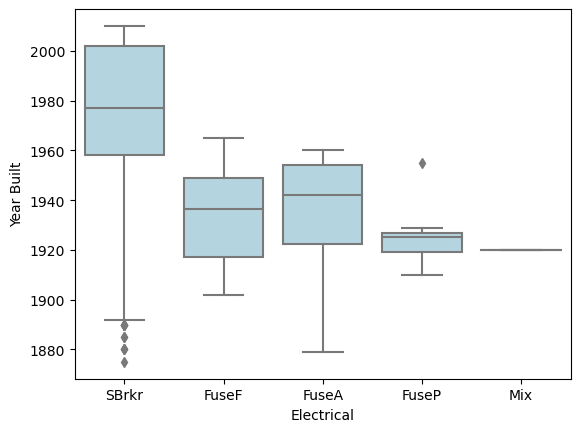

In [108]:
sns.boxplot(data=df, x="Electrical", y="Year Built", color="lightblue")
plt.show()

As expected, only houses built before 1960 have an electrical system other than SBrkr. Let's check the year of the house that doesn't have a feature, and fill the missing value based on the most frequent value for houses that have a similar construction year (+/- 10 years). I know there is only one missing value, but as an exercise, I will code this as if there were more than one missing values.

In [109]:
years = df.loc[df["Electrical"].isna(), "Year Built"]

for index, year in zip(years.index, years.values):
    df.loc[df.index==index, "Electrical"] = df.loc[df["Year Built"].between(year-10, year+10), "Electrical"].mode()[0]

In [110]:
df[ord_col].isna().sum()

Lot Shape         0
Utilities         0
Land Slope        0
Overall Qual      0
Overall Cond      0
Exter Qual        0
Exter Cond        0
Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     0
BsmtFin Type 1    0
BsmtFin Type 2    0
Heating QC        0
Electrical        0
Kitchen Qual      0
Functional        0
Fireplace Qu      0
Garage Finish     0
Garage Qual       0
Garage Cond       0
Paved Drive       0
dtype: int64

#### **b) Removing features with low impact on sale price**
Let's now plot the ordinal features to see if there are some that don't seem to have an influence on the sale price. We will make boxplots to investigate the relationship between the features and the sale price.

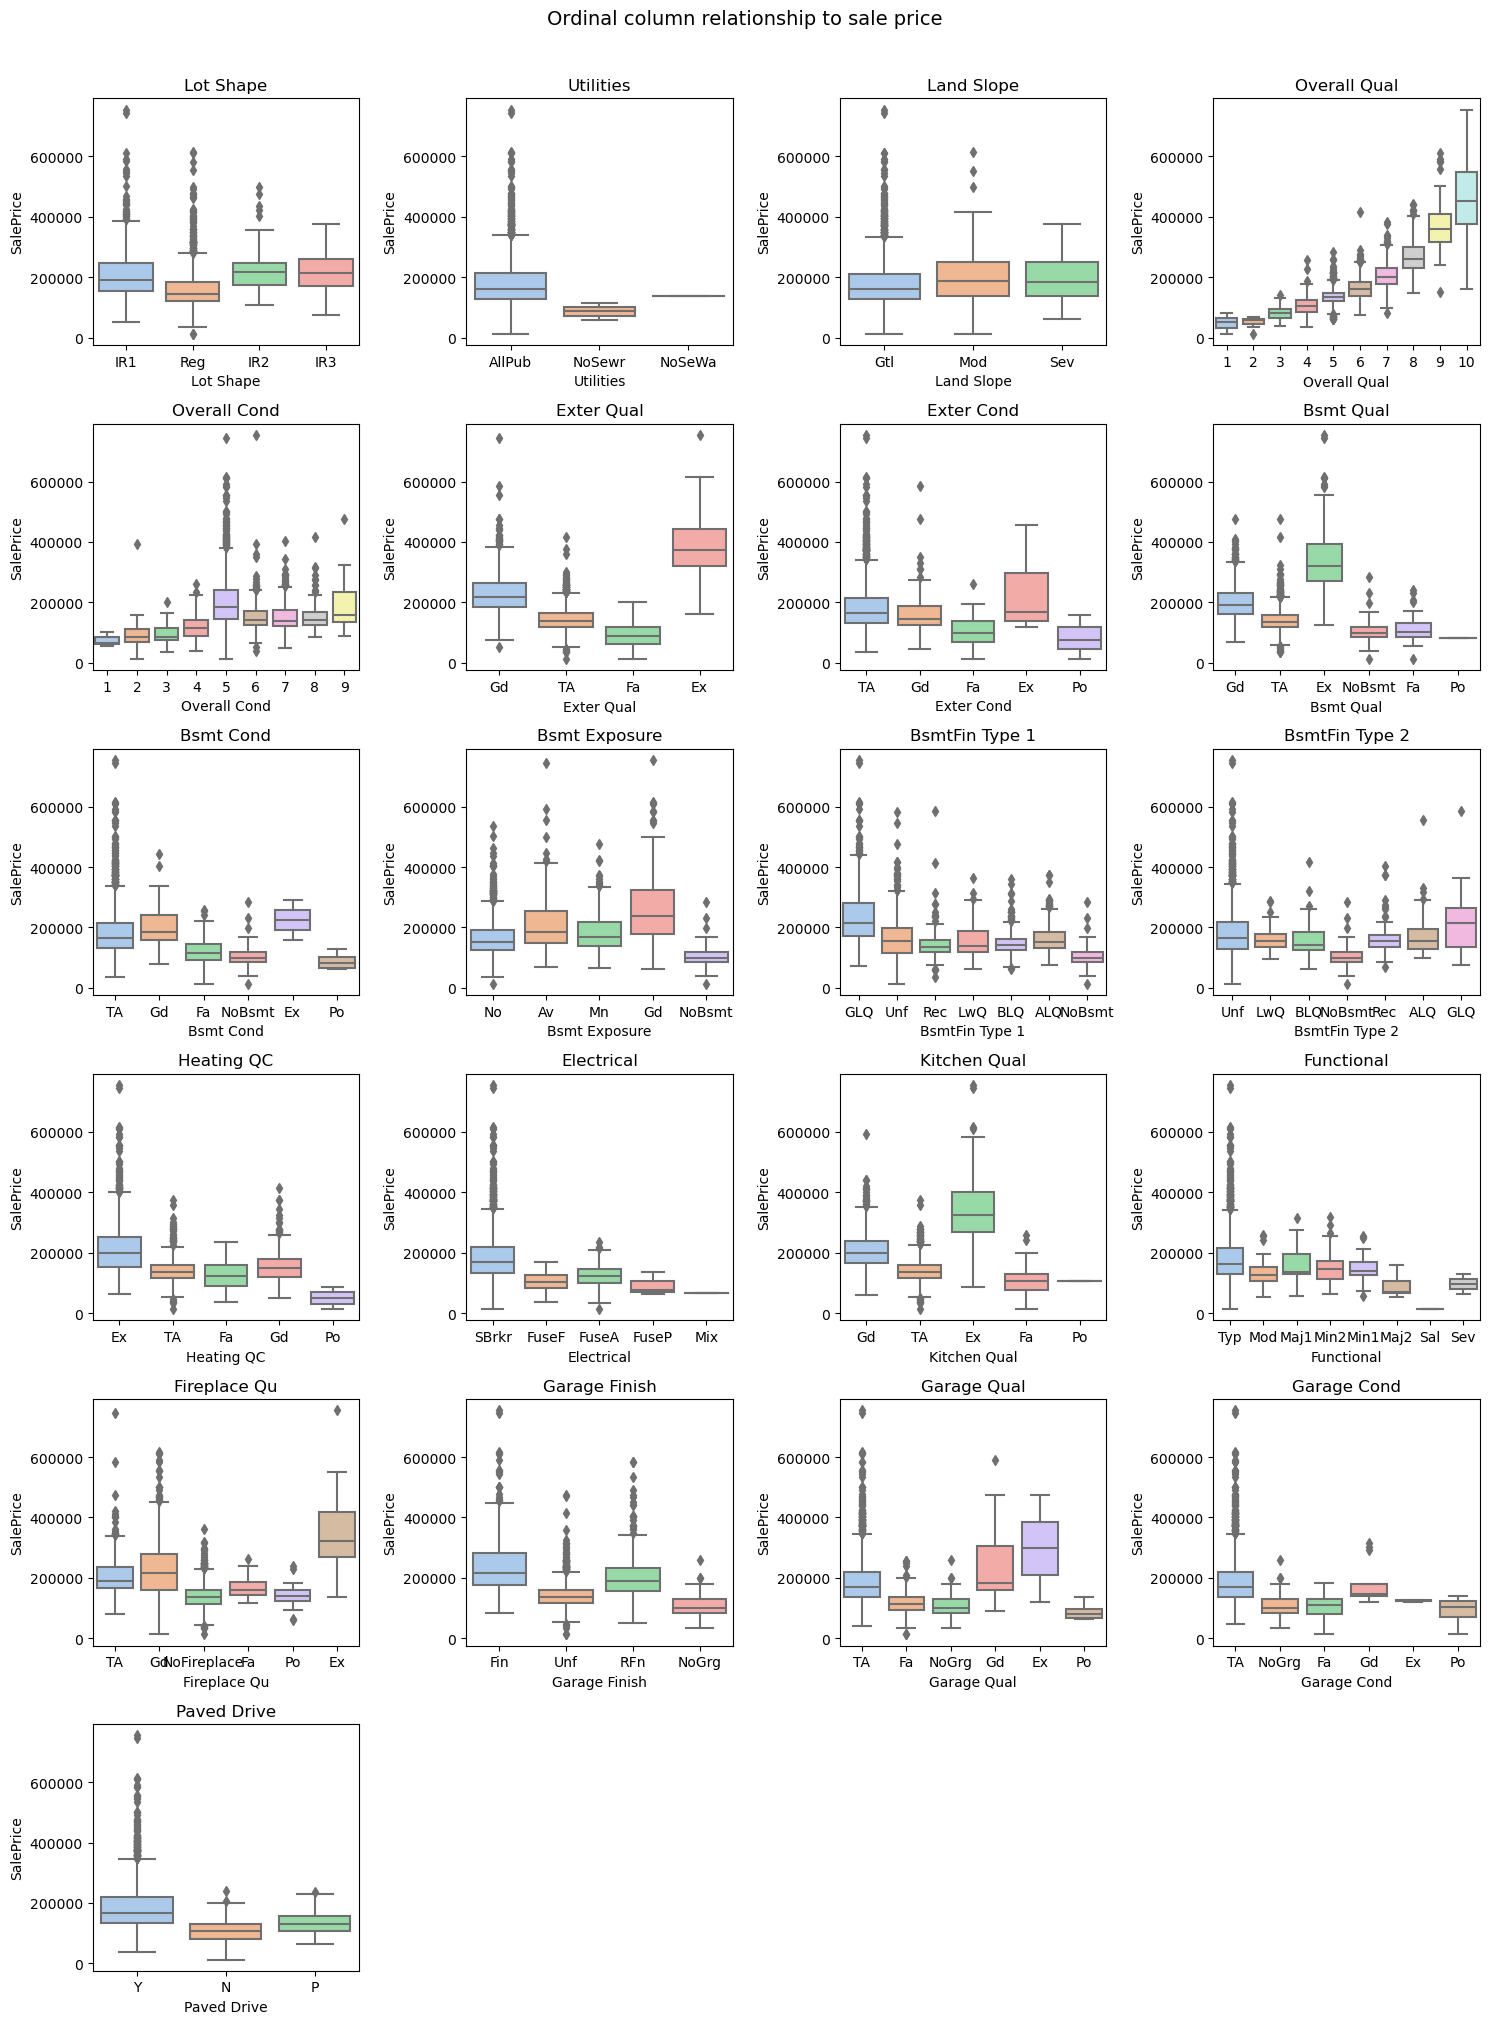

In [111]:
# Boxplots for the ordinal columns 
import math

# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(ord_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.flatten()

for ax, col in zip(axes, ord_col):
    sns.boxplot(data=df, x=col, y="SalePrice", ax=ax, palette="pastel")
    ax.set_title(col)

# Remove unused subplots
for j in range(len(ord_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Ordinal column relationship to sale price", fontsize=14, y=1.01) 
plt.tight_layout()
plt.show()

When looking at the variables one by one, it seems like several of them are not related to the sale price and could be removed. 

Here are the two features that I will remove from the data set as they have a low correlation to the sale price:
- Utilities (also because it seems to contain only one main category)
- Land Slope

In [112]:
df = df.drop(["Utilities", "Land Slope"], axis=1)
df_test = df_test.drop(["Utilities", "Land Slope"], axis=1)
ord_col = [col for col in ord_col if col not in ("Utilities", "Land Slope")]

feat_del_test.extend(["Utilities", "Land Slope"])
feat_del.extend(["Utilities", "Land Slope"])

## **3. Sale Price distribution**

### **3.1 Plotting the data**

To see if there are any clear outliers or wrong values in the sale price, I will now make two histograms for this variable, one with a linear axis, and one with a log axis

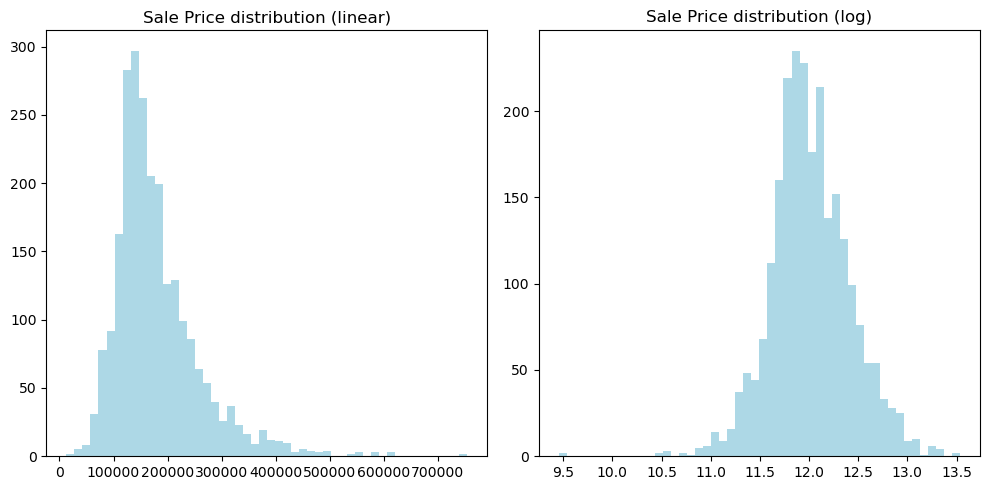

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(df.SalePrice, bins=50, color="lightblue")
axes[0].set_title("Sale Price distribution (linear)")

axes[1].hist(np.log1p(df.SalePrice), bins=50, color="lightblue")
axes[1].set_title("Sale Price distribution (log)")

plt.tight_layout()
plt.show()

We see that the distribution is skewed to the right. It might make sense to log transform this variable. Let's create a new feature that contains the log_transformed sale price and perform outlier removal using a z-score.

In [114]:
df["SalePrice_log"] = np.log(df["SalePrice"])

In [115]:
z_scores = (df["SalePrice_log"] - df["SalePrice_log"].mean()) / df["SalePrice_log"].std()
mask_SalePrice = abs(z_scores) > 3.5

print("using a z-score removes", mask_SalePrice.sum(), "entries")
print("this corresponds to", mask_SalePrice.sum() / len(df) * 100, "% of the data")

using a z-score removes 8 entries
this corresponds to 0.3308519437551696 % of the data


## **4. Rare value / outlier removal**

### **4.1 Identifying outliers for the continuous variables**

To assess the distribution of the remaining continuous variables and determine the best data cleaning strategy, I will plot histograms for each of the variables

/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/pandas/plotting/_core.py:1746: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


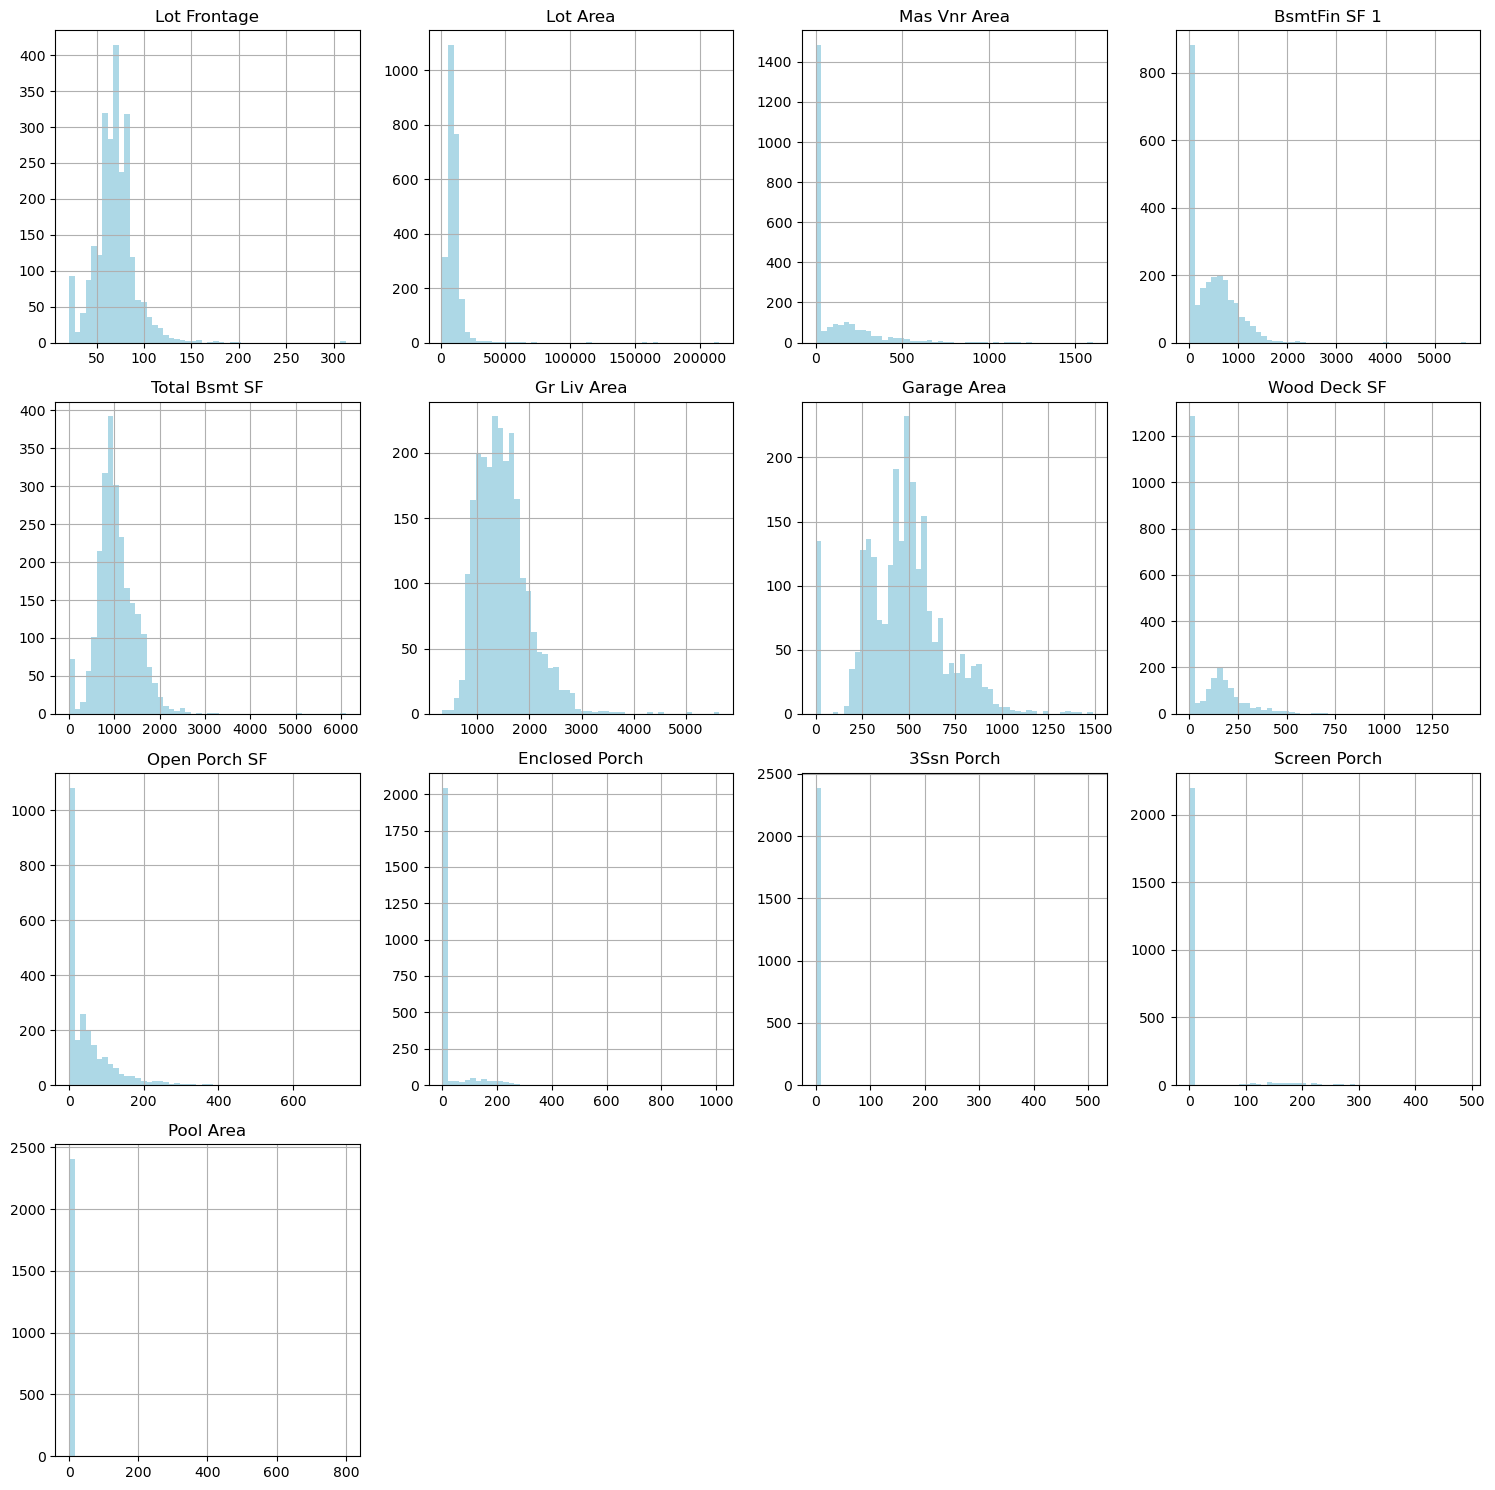

In [116]:
df[cont_col].hist(color="lightblue", bins=50, figsize = (15,15))
plt.tight_layout()
plt.show()

We notice that a lof of the features seem to contain a "tail" and have a some very large values. This is something we should adress. 

There are several ways to adress this. We could: 
- log transform the variables (this ensures that the z score is less skewed towards big values)
- remove outliers (using a z score)

Additionally, we notice that most of these variables have a lot of 0 in them (probably to indicate the absence of the item in the variable, i.e. a house that has a 0 in the wood deck SF variable likely doesn't have a wood deck). This will be treated in another step after outlier removal. 


##### **Log transforming the data**
We can see if it would make sense to log transform the data (to have distributions that more closely ressemble a gaussian distribution. 

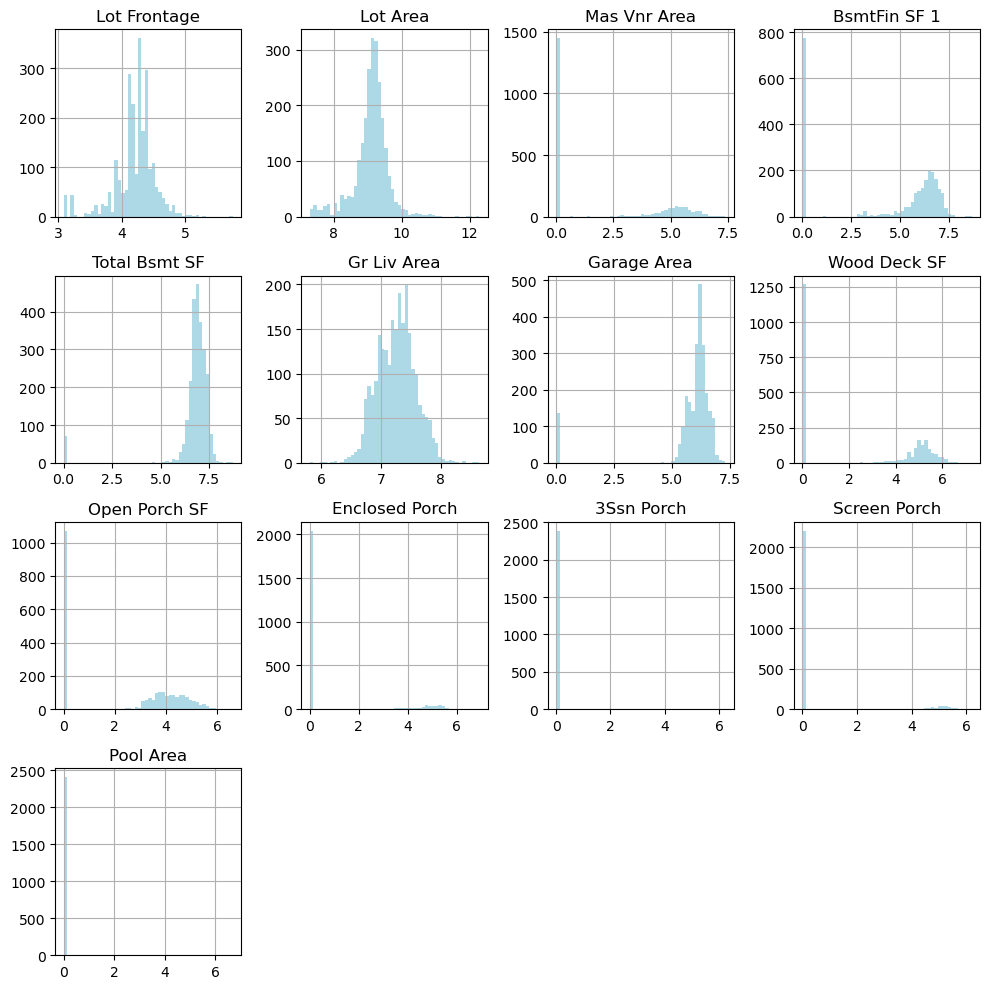

In [117]:
# Log transform the data
# plot the long transformed data
np.log1p(df[cont_col]).hist(color="lightblue", bins=50, figsize = (10,10))
plt.tight_layout()
plt.show()

By plotting the log transformed data, we directly see that a lot of the features benefit from being log transformed as the distribution now more closely resembles a gaussian distribution. 

Let's thus apply a log transformation to all of the continuous features for the **training** and the **test** set.

In [118]:
df[cont_col] = np.log1p(df[cont_col])
df_test[cont_col] = np.log1p(df_test[cont_col])

##### **Removing extreme values using a z score**

We would like to remove very big houses from the data set as they likely correspond to "mansions" that could negatively influence or models. To do this, we can remove entries that have a very large above ground surface area or lot area. 

Additionally, we can also remove entries that have a very small value for some of the features (such as lot frontage) as these are likely "out of the norm" property that might not be very useful for our model.

We can do this data cleaning step using a z score.

The features we wish to adress in this way are: 
- Lot Frontage
- Lot Area
- Gr Liv Area

Note that I am not applying this step to the features that contain a lot of 0s, as not only would this skew the z score, but also the 0s would likely be removed and they could contain valuable information. 

In [119]:
# calculate a z score
z_scores = (df.loc[:, ("Lot Frontage", "Lot Area", "Gr Liv Area")] - df.loc[:, ("Lot Frontage", "Lot Area", "Gr Liv Area")].mean(axis=0)) / df.loc[:, ("Lot Frontage", "Lot Area", "Gr Liv Area")].std(axis=0)
outliers = (np.abs(z_scores) > 3.5)

# create a row filter where a row will be removed if any one of the features contains an outlier
mask_cont = (outliers.sum(axis=1) > 0)

# Print the percentage / number of values we would remove using this setp
print("using a z score removes:", (mask_cont).sum(), "rows")
print("this corresponds to:", (mask_cont).sum() / len(df) * 100, "% of the data")

using a z score removes: 17 rows
this corresponds to: 0.7030603804797354 % of the data


This technique would seem to remove a reasonable amount of our data. let's save this filter. I will only apply it at the very end of the pipeline, so as not to influence downstream outlier / rare removal strategies.

In [120]:
# print the size of the data frame before filtering
print("shape before filtering:", df.shape)
print("shape after filtering:", df[~mask_cont].shape)

print(len(mask_cont))

shape before filtering: (2418, 66)
shape after filtering: (2401, 66)
2418


Let's plot the potential data after filtering to make sure our cleaning strategy has worked

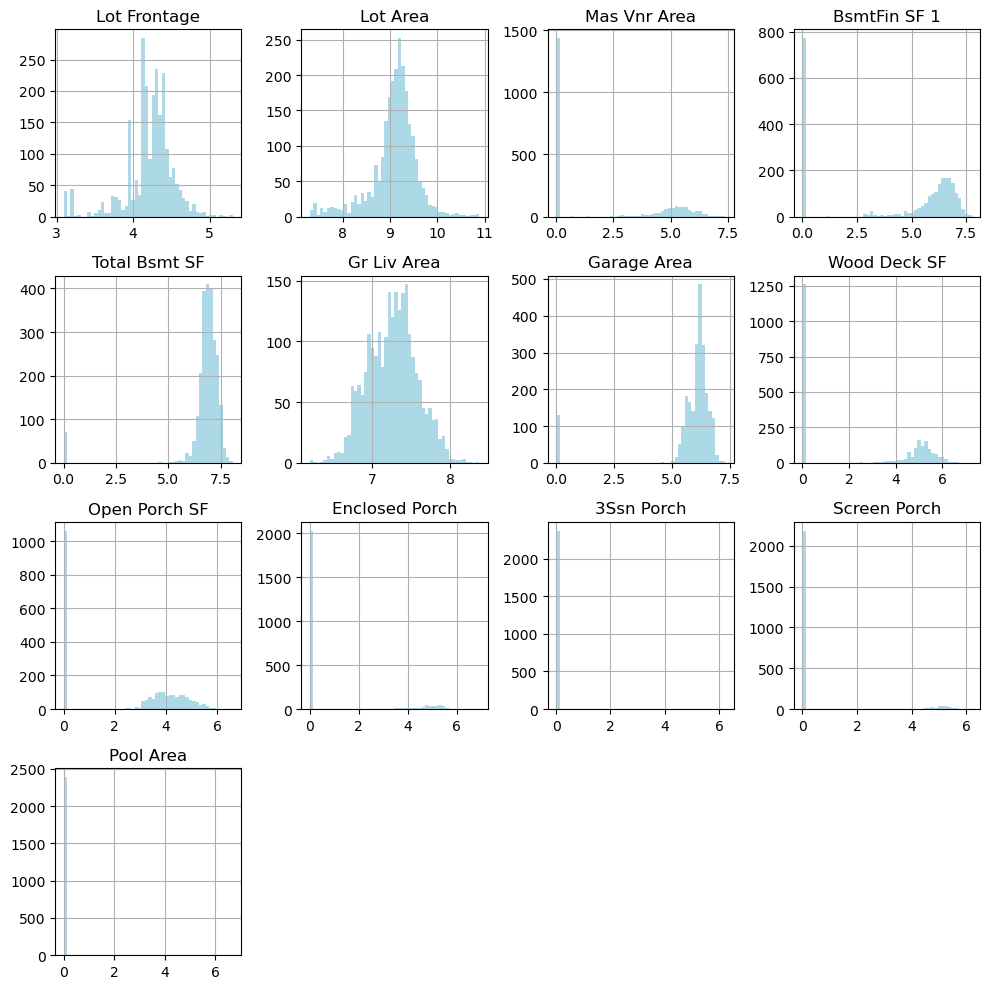

In [121]:
df.loc[~mask_cont, cont_col].hist(color="lightblue", bins=50, figsize = (10,10))
plt.tight_layout()
plt.show()

We see that our outlier removal strategy seems to work well, with the distributions now containing less extreme values. As mentioned above, I will **not** apply this cleaning strategy to the test set, as we don't want to artifically render this test set less complex and potentially increase model performance.

Additionally, I will only apply the mask at the very end of the pipeline, so as not to influence further rare value removal steps.

### **4.2 Identifying rare values for the discrete variables**

We will now have a look at the distribution of the data using histograms to see if there are any rare values that should be removed from the data set.

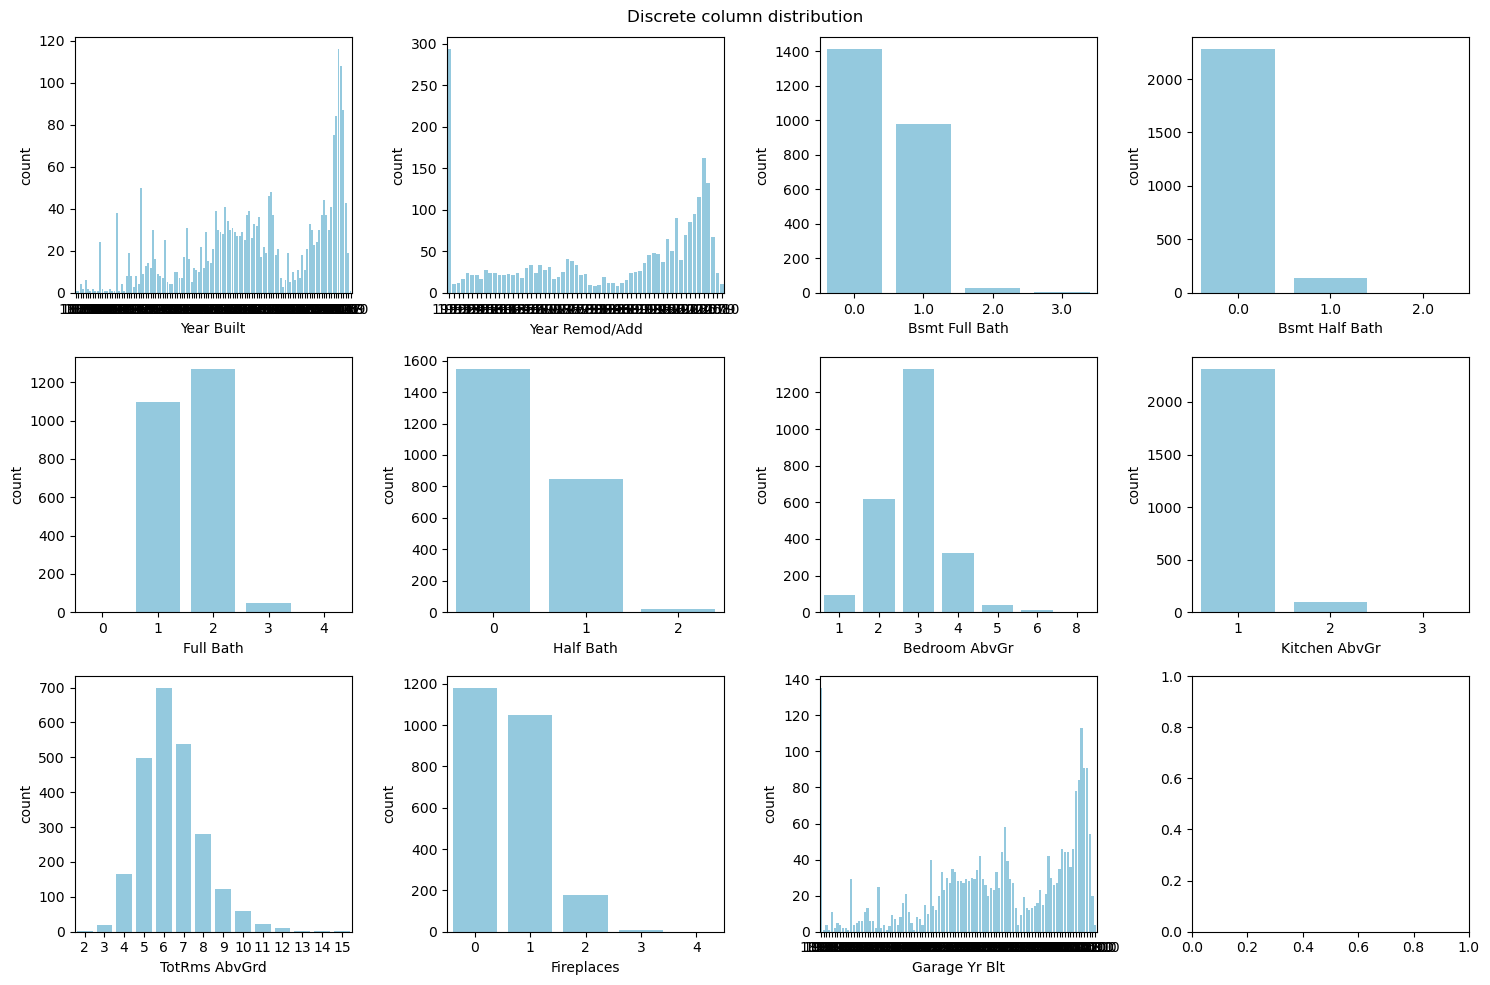

In [122]:
import math

# compute the number of rows and columns for the subplot
n_col = 4
n_rows = math.ceil(len(disc_col) / n_col)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for col, i in zip(disc_col, range(len(col))):
    sns.countplot(x=col, data=df, ax=axes[i], color="skyblue")

    
plt.suptitle("Discrete column distribution")
plt.tight_layout()
plt.show()

From what we can see of the data distribution, doing an outlier removal using a z-score would not make sense for a lot of these variables. 

For most of the features, it could make sense to remove the "uppermost" features if they contain less than a certain percentage of the data. I will thus choose to remove any "Category" that contains less than 0.5 percent of the data for the following features:
- Bsmt Full Bath
- Bsmt Half Bath
- Full Bath
- Half Bath
- Bedroom AbvGr
- Kitchen AbvGr
- TotRms AbvGr
- Fireplaces
- Garage Cars

For the Year Built, the Year Remod/Add and the Garage Yr Blt, let's do an outlier removal based on **quantiles** and remove the 2% of the houses with the oldest year in these categories. This method doesn't require the distribution to be normal and could thus be well suited for outlier removal.

Something else that stands out is that there are a lot of values seemingly around 1950 for the feature "Year Remod/Add". These values likely represent houses that haven't been renovated, but it might make more sense to replace this with the year the house was built.

##### **Rare category removal**

Let's remove categories that contain less than 0.25% of the data in the training set. let's first see which categories would be removed.

In [123]:
cols = ["Bsmt Full Bath", "Bsmt Half Bath", "Full Bath", "Half Bath", "Bedroom AbvGr", "Kitchen AbvGr", "TotRms AbvGrd", "Fireplaces", "Garage Cars"]

for col in cols:
    freq = df[col].value_counts(normalize=True)
    rare_vals = freq[freq < 0.0025].index
    print(col, rare_vals.values)

Bsmt Full Bath [3.]
Bsmt Half Bath [2.]
Full Bath [4 0]
Half Bath []
Bedroom AbvGr [8]
Kitchen AbvGr [3]
TotRms AbvGrd [15  2 14 13]
Fireplaces [4]
Garage Cars []


This looks like an appropriate filtering strategy. Let's apply it to our **training** set only.

In [124]:
for col in cols:
    freq = df[col].value_counts(normalize=True)
    rare_vals = freq[freq < 0.0025].index
    mask_rare = df[col].isin(rare_vals)

##### **Quantile-based outlier removal for Year Built and Garage Yr Built**

For these features, we can perform outlier removal using quantiles. We could remove the 1% houses with the oldest year of construction / Remodelling / garage construction for instance, as these are clearly extreme values. I don't want to remove any of the newer houses, as they could be useful for the model. Let's start by calculating the value corresponding to the lowest 1% quantile, and let's then filter any houses older than that. I will perform this outlier removal for the **training set** only.

Let's first create the three masks. We will apply them to our data set at the very end so as to not influence later outlier removal steps.

In [125]:
threshold_value = df["Year Built"].quantile(q=0.01)
print("we will remove houses built before", threshold_value)

mask_yr = df["Year Built"] <= threshold_value

print("this consists of", mask_yr.sum(), "houses (", mask_yr.sum()/len(df) * 100, "% )")

we will remove houses built before 1900.0
this consists of 45 houses ( 1.8610421836228286 % )


This seems like an appropriate filtering strategy. Let's keep this mask.

Let's apply this same strategy for the **Garage Yr Blt** feature, but without taking into account the houses with a value of 0 for this feature (as they don't have a garage)

In [126]:
threshold_value_grg = df.loc[df["Garage Yr Blt"] >0, "Garage Yr Blt"].quantile(q=0.01)
print("we will remove with garages houses built before", threshold_value)

mask_grg = (df["Garage Yr Blt"] > 0) & (df["Garage Yr Blt"] <= threshold_value_grg)

print("this consists of", mask_grg.sum(), "houses (", mask_grg.sum()/len(df) * 100, "% )")

we will remove with garages houses built before 1900.0
this consists of 24 houses ( 0.9925558312655087 % )


This seems like an appropriate filtering strategy, let's keep this mask

##### **Year Remod / Add Feature**
For this feature, We first need to investigate why there are so many values that are equal to 1950. Let's start by visualizing the feature again.

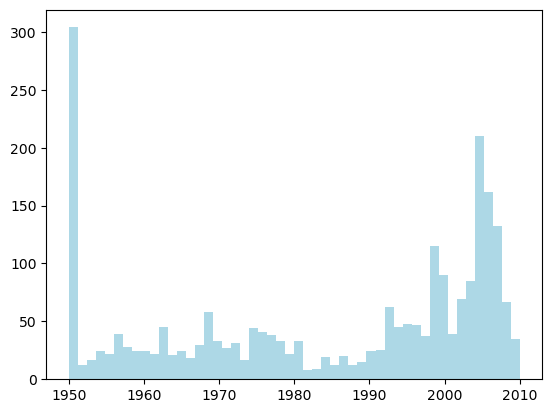

In [127]:
plt.hist(df["Year Remod/Add"], bins=50, color="lightblue")
plt.show()

This likely corresponds to houses that weren't remodelled. I think it would make more sense to either set this to 0, or set this to the year the house was built. I chose to set this to the year the house was built.

In [128]:
df.loc[df["Year Remod/Add"] == 1950, "Year Remod/Add"] = df.loc[df["Year Remod/Add"] == 1950, "Year Built"]
df_test.loc[df_test["Year Remod/Add"] == 1950, "Year Remod/Add"] = df_test.loc[df_test["Year Remod/Add"] == 1950, "Year Built"]

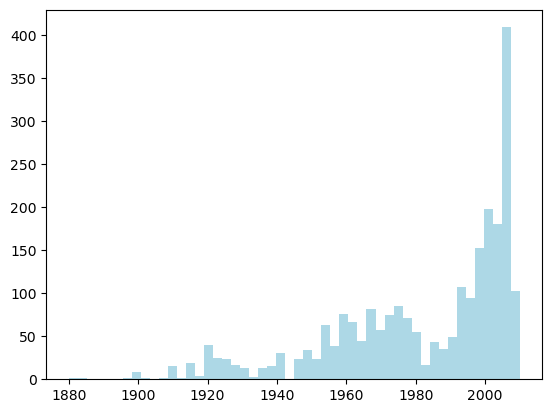

In [129]:
plt.hist(df["Year Remod/Add"], bins=50, color="lightblue")
plt.show()

This looks much better. We can now perform an outlier removal based on quantiles as we did above.

In [130]:
threshold_value_remod = df["Year Remod/Add"].quantile(q=0.01)
print("we will remove remodelled built before", threshold_value_remod)

mask_remod = df["Year Remod/Add"] <= threshold_value_remod

print("this consists of", mask_remod.sum(), "houses (", mask_remod.sum()/len(df) * 100, "% )")

we will remove remodelled built before 1910.0
this consists of 29 houses ( 1.1993382961124897 % )


Let's keep this mask and combine it with the two other masks we created. We will apply them at the end of the pipeline so as not to influence downstream rare value removal.

In [131]:
mask_disc = mask_rare | mask_yr | mask_remod | mask_grg
len(mask_disc)

2418

### **4.3 Identifying rare values for the nominal features**

For the nominal features, something we could do is group all rare values into a category called "other". Let's pool all values containing less than 0.25% of the data into a new value "other". 

If pooling the categories together still hasn't made an "other" cateogry containing more than 0.25% of the variable, let's remove it all together (these are not ordinary houses). 

We will also apply exactly the same approach to the test set, but using the information from the training set to determine if a category should be grouped into "other". This should work, as the decision about a category is taken only from the **training** set, and should thus prevent data leakage.
The only difference here is that we will **not** remove any categories from the test set. We don't want to artificially simplify this set as it would artificially increase model performance. 

In [132]:
mask_nom = pd.Series(False, index=df.index)

for col in nom_col:
    rare_values = df[col].value_counts(normalize=True) < 0.0025
    rare_values = rare_values[rare_values].index
    
    # If there is more than 1 rare index, group the different categories into a category "other". 
    if len(rare_values) > 1 :
        df.loc[df[col].isin(rare_values), col] = "other"
        df_test.loc[df_test[col].isin(rare_values), col] = "other"
        
        # Create a mask to remove the category "other" if it still contains less than 0.25% of the data in the training set
        if ((df[col] == "other").sum() / len(df[col])) < 0.0025:
            mask_nom |= (df[col] == "other")
            
    # If there is only one rare category, remove it all together
    else:
        mask_nom |= df[col].isin(rare_values)

print(len(mask_nom))

2418


Let's visualize the data once more to make sure that we now have the "other categories". Let's also visualize what our filtering would look like.

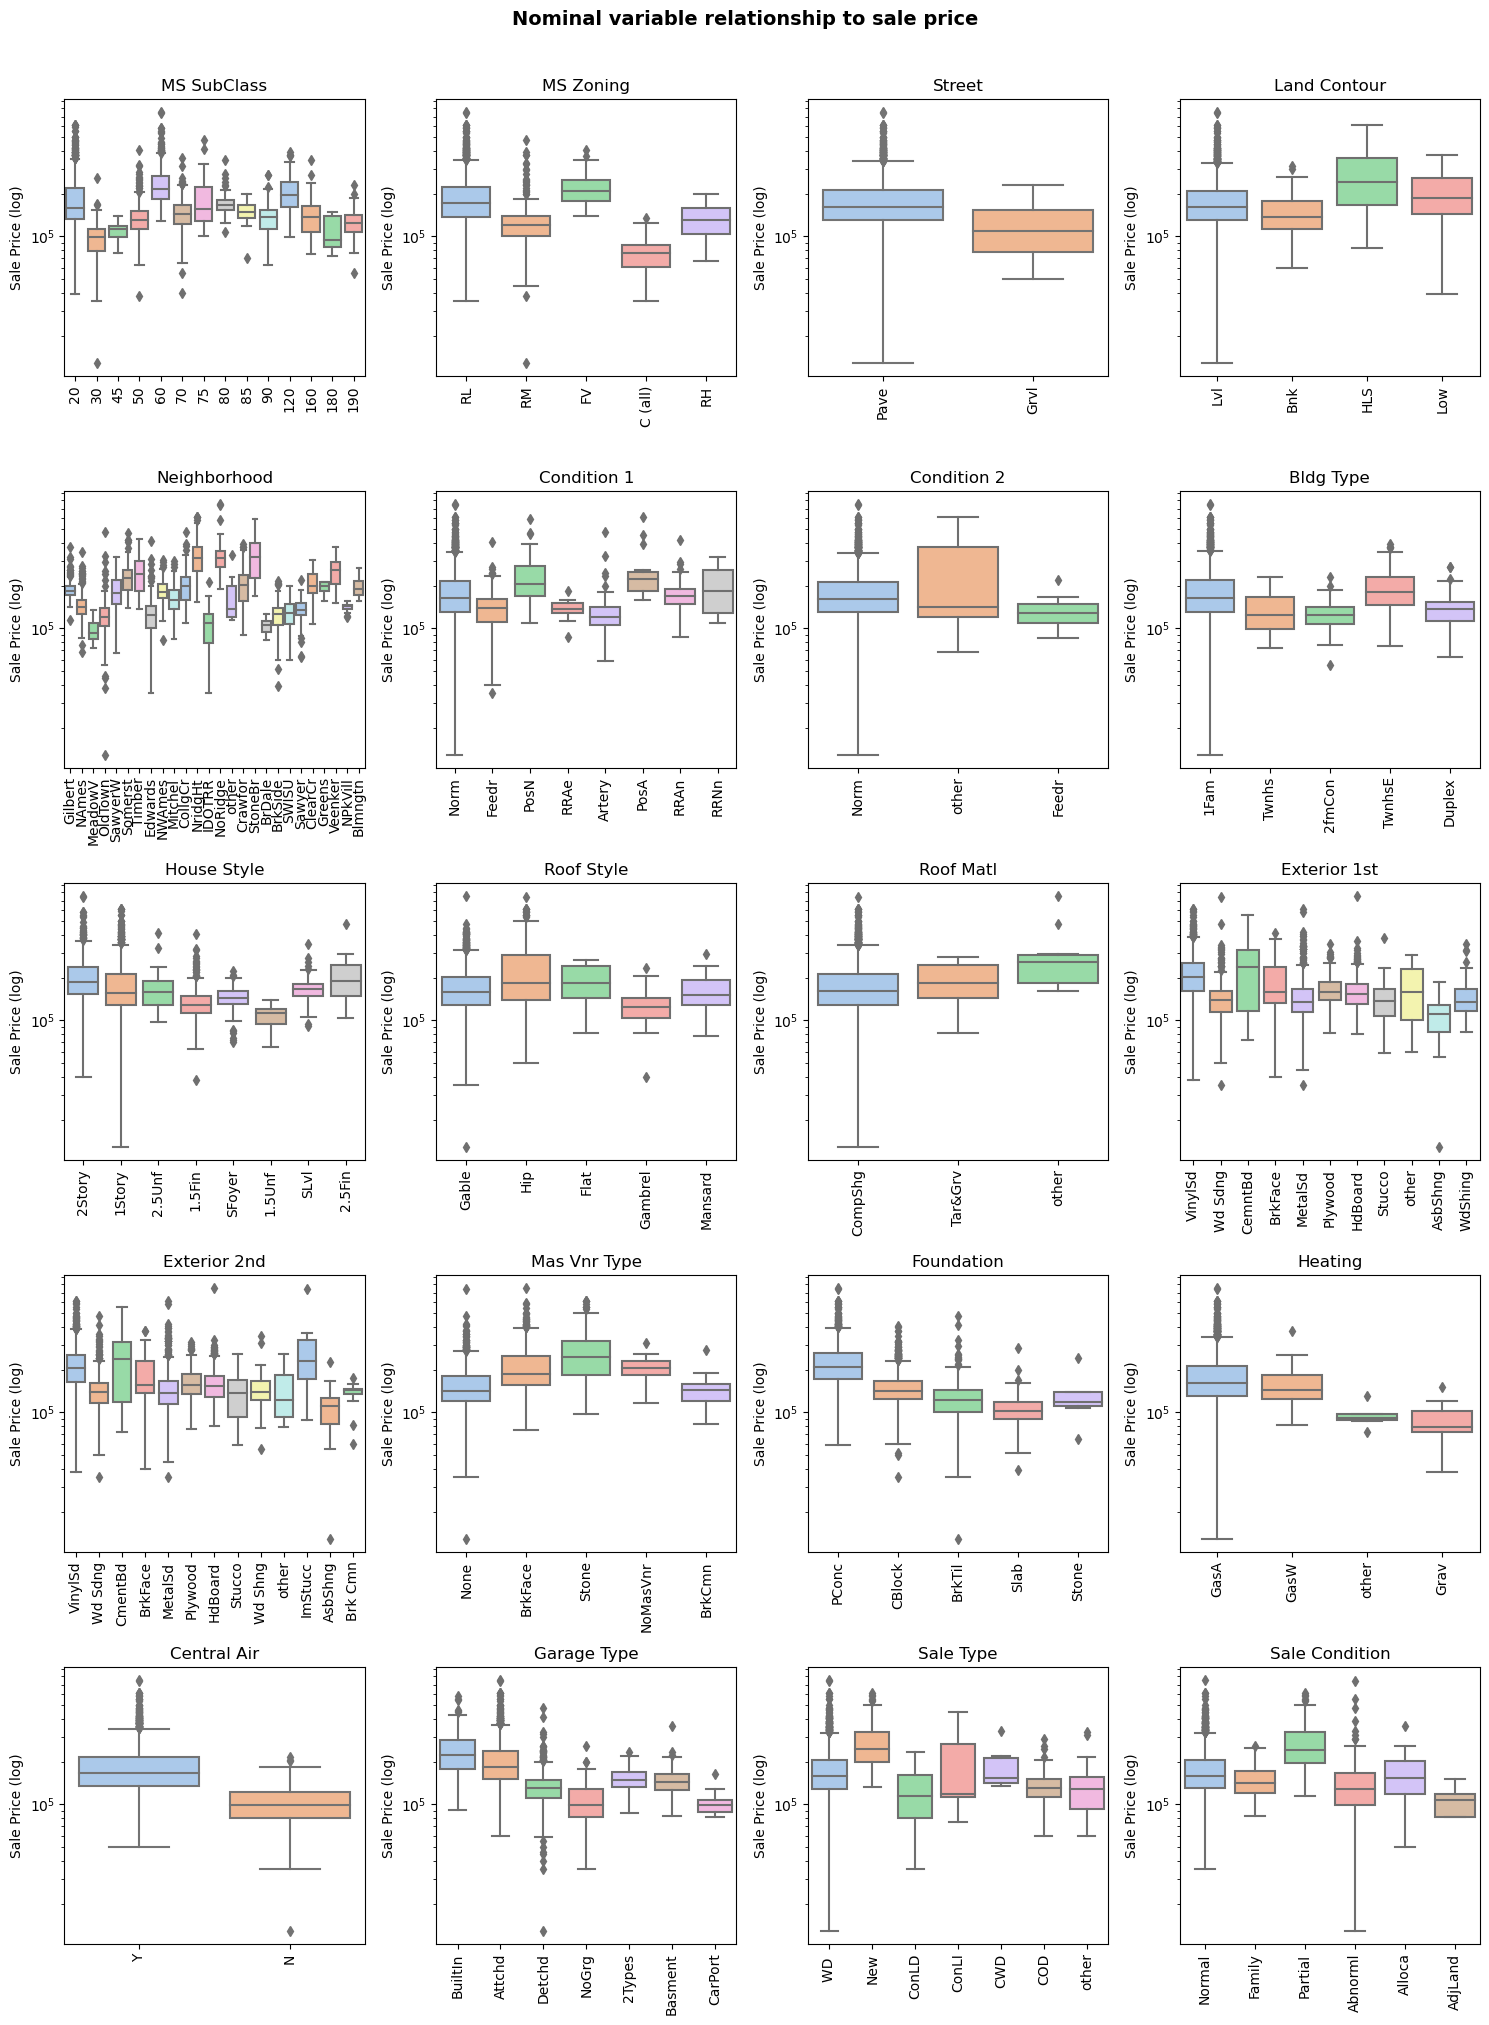

In [133]:
# Boxplots for the nominal columns 
import math

# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(nom_col) / n_col)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.flatten()

for col, i in zip(nom_col, range(len(nom_col))):
        sns.boxplot(data=df[~mask_nom], x=col, y="SalePrice", ax=axes[i], palette="pastel")
        axes[i].set_title(col)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Sale Price (log)")
        axes[i].set_yscale("log")
        axes[i].tick_params(axis='x', rotation=90)

# Remove unused subplots
for j in range(len(nom_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Nominal variable relationship to sale price", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

We see that we now have the category "other" for most variables. 

Our filtering strategy would work, but also makes some features useless for the model. This is the case for the feature "Street" that would now only carries one category, or the features "Condition 2" and "Roof Matl" that would only contain two categories not related to sale price. We can drop these features from the data set.  

In [134]:
df = df.drop(["Street", "Condition 2", "Roof Matl"], axis=1)
df_test = df_test.drop(["Street", "Condition 2", "Roof Matl"], axis=1)
nom_col = [col for col in nom_col if col not in ("Street", "Condition 2", "Roof Matl")]

feat_del_test.extend(["Street", "Condition 2", "Roof Matl"])
feat_del.extend(["Street", "Condition 2", "Roof Matl"])

### **4.4 Identifying rare values for the ordinal features**

Since the values are ordinal, Creating a new category called "rare" as we did for the nominal values doesn't necessarily make sense here. The best approach would like to filter out any category that contains less than 0.25% of the data. 

We can then apply this filter to **only the training set**.


In [135]:
mask_ord = pd.Series(False, index=df.index)

for col in ord_col:
    rare_values = df[col].value_counts(normalize=True) < 0.0025
    rare_values = rare_values[rare_values].index
    mask_ord |= df[col].isin(rare_values)

Let's now plot the features again, to see what our filtering would do.

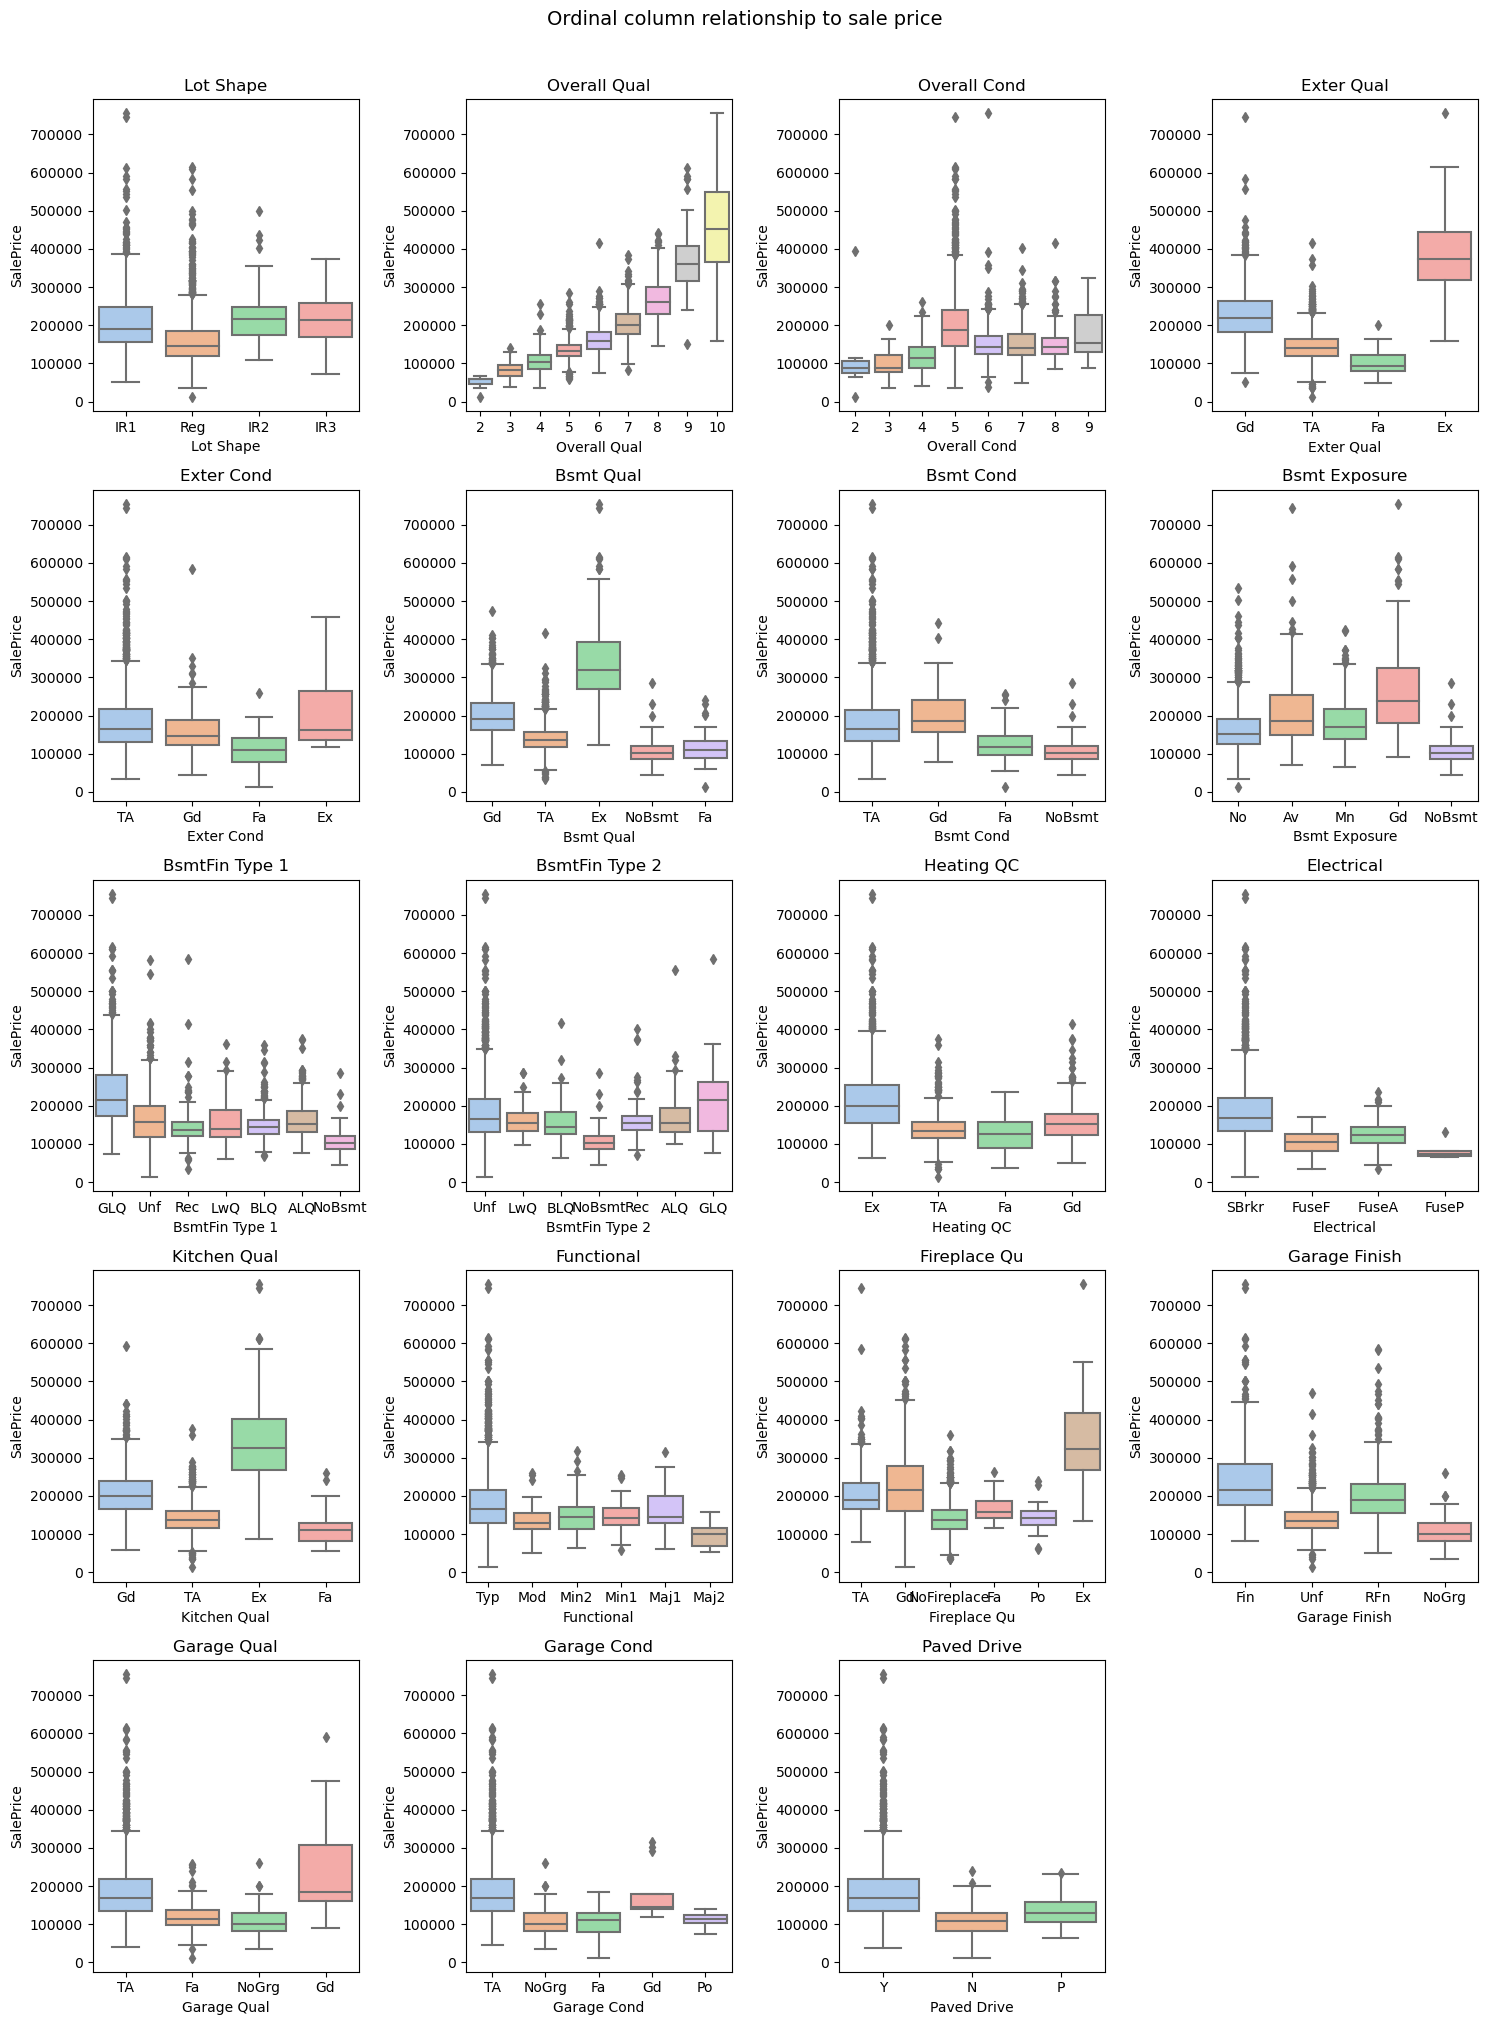

In [136]:
# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(ord_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.flatten()

for ax, col in zip(axes, ord_col):
    sns.boxplot(data=df[~mask_ord], x=col, y="SalePrice", ax=ax, palette="pastel")
    ax.set_title(col)

# Remove unused subplots
for j in range(len(ord_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Ordinal column relationship to sale price", fontsize=14, y=1.01) 
plt.tight_layout()
plt.show()

### **4.5 Filtering the data**

We are now ready to filter the data based on the 5 masks we have created. Let's do it!

In [137]:
mask = mask_nom | mask_ord | mask_cont | mask_disc | mask_SalePrice

print("our outlier / rare value removal removes", mask.sum(), "entries")
print("this corresponds to", mask.sum() / len(df) * 100, "% of the dataset")

our outlier / rare value removal removes 135 entries
this corresponds to 5.583126550868486 % of the dataset


In [138]:
df = df[~mask]

Finally, let's also remove some entries specifically based on the documentation of the ames data set. 
"There are 5 observations that an instructor may wish to remove from the data set before giving it to students (a plot of SALE PRICE versus GR LIV AREA will indicate them quickly). Three of them are true outliers (Partial Sales that likely don’t represent actual market values) and two of them are simply unusual sales (very large houses priced relatively appropriately). I would recommend removing any houses with more than 4000 square feet from the data set (which eliminates these 5 unusual observations) before assigning it to students."

In [139]:
df = df[df["Gr Liv Area"] < 4000]

## **5. Summary**

Let's check how much of our data we removed during this section.

In [140]:
# original data frame shape
print("original training data frame shape:", data.shape)
print("final training data frame shape:", df.shape)

print("original test data frame shape:", data_test.shape)
print("final test data frame shape:", df_test.shape)

print("we removed", (1-(df.shape[0] / data.shape[0])) * 100, "% of the training data")
print("we removed", (1-(df_test.shape[0] / data_test.shape[0])) * 100, "% of the training data")

original training data frame shape: (2430, 82)
final training data frame shape: (2283, 63)
original test data frame shape: (500, 81)
final test data frame shape: (500, 61)
we removed 6.0493827160493785 % of the training data
we removed 0.0 % of the training data


In [141]:
print("the following features were removed from the training data set:", str(feat_del))
print("This corresponds to", len(feat_del), "features")

the following features were removed from the training data set: ['PID', 'Order', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Low Qual Fin SF', 'Misc Val', '1st Flr SF', '2nd Flr SF', 'Yr Sold', 'Mo Sold', 'Lot Config', 'Pool QC', 'Fence', 'Utilities', 'Land Slope', 'Street', 'Condition 2', 'Roof Matl']
This corresponds to 18 features


In [142]:
print("the following features were removed from the test data set:", str(feat_del_test))
print("This corresponds to", len(feat_del_test), "features")

the following features were removed from the test data set: ['PID', 'Order', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Low Qual Fin SF', 'Misc Val', '1st Flr SF', '2nd Flr SF', 'Yr Sold', 'Mo Sold', 'Lot Config', 'Pool QC', 'Fence', 'Utilities', 'Land Slope', 'Street', 'Condition 2', 'Roof Matl']
This corresponds to 18 features


We see that we removed 18 columns from the training and the test data set. We removed 6.04 % of the training data set, but did not remove any entries from the test data set. This looks good, let's now save the cleaned data set.

## **5) Saving the cleaned data**
Let's now save the cleaned data sets.

In [143]:
df.to_csv("clean_df.csv", index=False)
df_test.to_csv("clean_df_test.csv", index=False)